# ResNet-50_ver4

In [ ]:
#=============================
# 1. Drive 마운트, 설치, 경로 세팅
#===============================
from google.colab import drive
drive.mount('/content/drive')

!pip -q install timm scikit-learn


Mounted at /content/drive


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/ResNet-50_Attention/ver4/best_model_recall.pth"
BASE_DIR   = "/content/drive/MyDrive/ColabNotebooks/RFMiD_A/EDA_2/dataset_1"
TEST_CSV   = "/content/drive/MyDrive/ColabNotebooks/RFMiD_A/EDA_2/dataset_1/manifest_test.csv"
TEST_IMG_DIR = "/content/drive/MyDrive/ColabNotebooks/RFMiD_A/EDA_2/dataset_1/test"

import os
assert os.path.exists(MODEL_PATH), f"MODEL_PATH not found: {MODEL_PATH}"
assert os.path.exists(TEST_CSV), f"TEST_CSV not found: {TEST_CSV}"
assert os.path.exists(TEST_IMG_DIR), f"TEST_IMG_DIR not found: {TEST_IMG_DIR}"
print("✅ Paths OK")

✅ Paths OK


In [ ]:
#============================================================
# 2. CSV 읽고 컬럼 자동 선택 + test 폴더 이미지 인덱싱
#============================================================
import pandas as pd, glob, os, re

df = pd.read_csv(TEST_CSV)
print("CSV columns:", df.columns.tolist())
print(df.head(3))

# img/label 컬럼 자동 추정
img_col_candidates = ["img_id", "image_id", "image", "filename", "file", "path", "img"]
label_col_candidates = ["label", "DR", "target", "y", "gt", "class"]

img_col = next((c for c in img_col_candidates if c in df.columns), None)
label_col = next((c for c in label_col_candidates if c in df.columns), None)

if img_col is None or label_col is None:
    raise ValueError(f"❌ 컬럼 자동 매칭 실패. img_col={img_col}, label_col={label_col}. "
                     f"columns={df.columns.tolist()}")

print("Using img_col:", img_col, "| label_col:", label_col)

# test 폴더 안의 실제 이미지 파일 수집 (하위폴더까지)
img_files = []
for ext in ["png", "jpg", "jpeg", "PNG", "JPG", "JPEG"]:
    img_files += glob.glob(os.path.join(TEST_IMG_DIR, "**", f"*.{ext}"), recursive=True)

assert len(img_files) > 0, f"❌ {TEST_IMG_DIR} 아래에서 이미지 파일을 못 찾음"
print(f"✅ Found {len(img_files)} images under TEST_IMG_DIR")

# 파일명 인덱스 만들기 (filename/stem 기반)
name2path = {}
stem2paths = {}
for p in img_files:
    base = os.path.basename(p)             # 예: 00001.png
    stem = os.path.splitext(base)[0]       # 예: 00001
    name2path[base] = p
    stem2paths.setdefault(stem, []).append(p)

def resolve_path(v):
    v = str(v)
    base = os.path.basename(v)

    # 1) base가 filename(확장자 포함)으로 일치
    if base in name2path:
        return name2path[base]

    # 2) 확장자 제거 stem으로 일치
    stem = os.path.splitext(base)[0]
    if stem in stem2paths:
        return stem2paths[stem][0]

    # 3) 숫자면 zero-padding 시도: 1 -> 00001 등
    if re.fullmatch(r"\d+", stem):
        for pad in [5, 4, 6, 3]:
            z = stem.zfill(pad)
            if z in stem2paths:
                return stem2paths[z][0]

    # 4) 마지막: 혹시 v 자체가 stem일 수도(경로 없이) -> 그대로 시도
    if v in stem2paths:
        return stem2paths[v][0]

    return None

# 매칭 성공률 체크
mapped = df[img_col].apply(resolve_path)
ok_rate = mapped.notna().mean()
print(f"✅ mapping success rate: {ok_rate*100:.1f}%")

# 실패 샘플 몇 개 보기(0%면 폴더가 다르거나 csv 값 체계가 다름)
fails = df.loc[mapped.isna(), img_col].head(10).tolist()
if fails:
    print("❌ mapping failed examples:", fails)

CSV columns: ['split', 'img_id', 'label', 'final_path', 'orig_path', 'mode', 'width', 'height']
  split  img_id  label                                         final_path  \
0  test       1      1  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...   
1  test      10      1  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...   
2  test     101      1  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...   

                                           orig_path mode  width  height  
0  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...  RGB    512     512  
1  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...  RGB    512     512  
2  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...  RGB    512     512  
Using img_col: img_id | label_col: label
✅ Found 640 images under TEST_IMG_DIR
✅ mapping success rate: 100.0%


In [ ]:
#==============================================================
# 3. Dataset /Loader
#===============================================================
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 512
BATCH_SIZE = 16

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class TestDataset(Dataset):
    def __init__(self, df, img_col, label_col, transform):
        self.df = df.copy().reset_index(drop=True)
        self.img_col = img_col
        self.label_col = label_col
        self.transform = transform

        self.df["_path"] = self.df[self.img_col].apply(resolve_path)
        before = len(self.df)
        self.df = self.df[self.df["_path"].notna()].reset_index(drop=True)
        after = len(self.df)
        print(f"✅ Kept {after}/{before} samples after path mapping")

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        p = self.df.loc[idx, "_path"]
        y = float(self.df.loc[idx, self.label_col])
        img = Image.open(p).convert("RGB")
        img = self.transform(img)
        return img, torch.tensor(y, dtype=torch.float32)

test_dataset = TestDataset(df, img_col, label_col, test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


✅ Kept 640/640 samples after path mapping


In [ ]:
# state_dict 키 확인 -> 모델 유형과 맞는지 확인
print(list(state.keys())[:30])


['features.0.weight', 'features.1.weight', 'features.1.bias', 'features.1.running_mean', 'features.1.running_var', 'features.1.num_batches_tracked', 'features.4.0.conv1.weight', 'features.4.0.bn1.weight', 'features.4.0.bn1.bias', 'features.4.0.bn1.running_mean', 'features.4.0.bn1.running_var', 'features.4.0.bn1.num_batches_tracked', 'features.4.0.conv2.weight', 'features.4.0.bn2.weight', 'features.4.0.bn2.bias', 'features.4.0.bn2.running_mean', 'features.4.0.bn2.running_var', 'features.4.0.bn2.num_batches_tracked', 'features.4.0.conv3.weight', 'features.4.0.bn3.weight', 'features.4.0.bn3.bias', 'features.4.0.bn3.running_mean', 'features.4.0.bn3.running_var', 'features.4.0.bn3.num_batches_tracked', 'features.4.0.downsample.0.weight', 'features.4.0.downsample.1.weight', 'features.4.0.downsample.1.bias', 'features.4.0.downsample.1.running_mean', 'features.4.0.downsample.1.running_var', 'features.4.0.downsample.1.num_batches_tracked']


In [ ]:
# 모델 유형 =/= state_dict 키
# 모델 유형과 state_dict 키 맞추는 작업
import torch
import timm
from collections import OrderedDict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model("resnet50", pretrained=False, num_classes=1).to(device)

ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
state = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt

def remap_key(k: str) -> str:
    # 공통 prefix 제거
    if k.startswith("module."):
        k = k.replace("module.", "", 1)
    if k.startswith("backbone."):
        k = k.replace("backbone.", "", 1)

    # ✅ torchvision-style wrapper: features.{idx} -> timm resnet parts
    # features = [conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4]
    if k.startswith("features.0."):
        return k.replace("features.0.", "conv1.", 1)
    if k.startswith("features.1."):
        return k.replace("features.1.", "bn1.", 1)
    # relu / maxpool은 파라미터가 없어서 보통 state_dict에 없음(있어도 무시)
    if k.startswith("features.4."):
        return k.replace("features.4.", "layer1.", 1)
    if k.startswith("features.5."):
        return k.replace("features.5.", "layer2.", 1)
    if k.startswith("features.6."):
        return k.replace("features.6.", "layer3.", 1)
    if k.startswith("features.7."):
        return k.replace("features.7.", "layer4.", 1)

    # 분류기 이름 통일 (학습 코드에 따라 classifier / head 일 수 있음)
    if k.startswith("classifier."):
        return k.replace("classifier.", "fc.", 1)
    if k.startswith("head."):
        return k.replace("head.", "fc.", 1)

    return k

# remap 적용
new_state = OrderedDict((remap_key(k), v) for k, v in state.items())

# (옵션) fc shape mismatch 나면 fc만 버리고 backbone만 로드
model_sd = model.state_dict()
filtered_state = {k: v for k, v in new_state.items()
                  if k in model_sd and v.shape == model_sd[k].shape}

missing, unexpected = model.load_state_dict(filtered_state, strict=False)
print("missing keys:", len(missing), "| unexpected keys:", len(unexpected))
print("✅ loaded (strict=False)")

model.eval()


missing keys: 2 | unexpected keys: 0
✅ loaded (strict=False)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [ ]:
#==============================================================
# 4. ResNet-50 로드(backbone prefix 제거 포함)
#==============================================================
import torch
import torch.nn as nn
import torchvision.models as models
from collections import OrderedDict

class ResNet50_Custom(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights=None)

        # backbone을 features로 묶기 (체크포인트 키와 맞춤)
        self.features = nn.Sequential(
            base.conv1,   # features.0
            base.bn1,     # features.1
            base.relu,    # (파라미터 없음 → 키에 안 잡힘)
            base.maxpool, # (파라미터 없음)
            base.layer1,  # features.4
            base.layer2,  # features.5
            base.layer3,  # features.6
            base.layer4,  # features.7
            base.avgpool  # (파라미터 없음)
        )

        # 체크포인트 classifier.*에 맞춘 헤드
        self.classifier = nn.Sequential(
            nn.Flatten(),            # classifier.0 (파라미터 없음)
            nn.Linear(2048, 512),    # classifier.1
            nn.ReLU(),               # classifier.2 (파라미터 없음)
            nn.Dropout(p=0.2),       # classifier.3 (파라미터 없음)
            nn.Linear(512, 1)        # classifier.4
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

device = torch.device("cpu")
model = ResNet50_Custom().to(device)

ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
state = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt

# prefix 제거(있을 경우)
new_state = OrderedDict()
for k, v in state.items():
    k2 = k
    if k2.startswith("module."):
        k2 = k2.replace("module.", "", 1)
    if k2.startswith("backbone."):
        k2 = k2.replace("backbone.", "", 1)
    new_state[k2] = v

missing, unexpected = model.load_state_dict(new_state, strict=False)
print("missing:", len(missing), "unexpected:", len(unexpected))


missing: 0 unexpected: 14


In [ ]:
#unexpected 된 key 확인
print("unexpected keys (all):")
for k in unexpected:
    print(k)


unexpected keys (all):
attention.attention.0.weight
attention.attention.0.bias
attention.attention.1.weight
attention.attention.1.bias
attention.attention.1.running_mean
attention.attention.1.running_var
attention.attention.1.num_batches_tracked
attention.attention.3.weight
attention.attention.3.bias
attention.attention.4.weight
attention.attention.4.bias
attention.attention.4.running_mean
attention.attention.4.running_var
attention.attention.4.num_batches_tracked


In [ ]:
import torch

ckpt = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
state = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt

# prefix 정리(있을 수 있으니)
def strip_prefix(k):
    for p in ["module.", "backbone."]:
        if k.startswith(p):
            return k.replace(p, "", 1)
    return k

state = {strip_prefix(k): v for k, v in state.items()}

for k in sorted([k for k in state.keys() if k.startswith("attention.attention")]):
    print(k, tuple(state[k].shape))


attention.attention.0.bias (256,)
attention.attention.0.weight (256, 2048, 1, 1)
attention.attention.1.bias (256,)
attention.attention.1.num_batches_tracked ()
attention.attention.1.running_mean (256,)
attention.attention.1.running_var (256,)
attention.attention.1.weight (256,)
attention.attention.3.bias (2048,)
attention.attention.3.weight (2048, 256, 1, 1)
attention.attention.4.bias (2048,)
attention.attention.4.num_batches_tracked ()
attention.attention.4.running_mean (2048,)
attention.attention.4.running_var (2048,)
attention.attention.4.weight (2048,)


In [ ]:
# unexpected된 key 해결
import torch
import torch.nn as nn
import torchvision.models as models
from collections import OrderedDict

def strip_prefix_state(state):
    new_state = OrderedDict()
    for k, v in state.items():
        k2 = k
        if k2.startswith("module."):
            k2 = k2.replace("module.", "", 1)
        if k2.startswith("backbone."):
            k2 = k2.replace("backbone.", "", 1)
        new_state[k2] = v
    return new_state

def build_classifier_from_state(state):
    """
    checkpoint의 classifier.* weight shape를 읽어서
    Linear(in,out)을 자동으로 맞춤.
    기대: classifier.1.weight, classifier.4.weight 같은 형태 (MLP)
    """
    w1 = state.get("classifier.1.weight", None)
    w4 = state.get("classifier.4.weight", None)

    if w1 is None or w4 is None:
        # fallback: 가장 흔한 기본값(필요하면 여기 조정)
        return nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(512, 1),
        )

    # Linear weight shape: (out_features, in_features)
    out1, in1 = w1.shape
    out4, in4 = w4.shape

    # 보통 마지막 out4는 1이어야 이진분류
    # in4는 중간 hidden dim (= out1)과 같아야 정상
    hidden = out1
    assert in1 == 2048, f"classifier.1 입력이 2048이 아님: {in1}"
    assert out4 == 1, f"마지막 출력이 1이 아님: {out4}"
    assert in4 == hidden, f"classifier.4 입력({in4})이 hidden({hidden})과 다름"

    # Dropout p/활성화 종류는 state_dict에 안 들어가므로 일반적인 값 사용
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(2048, hidden),  # classifier.1
        nn.ReLU(inplace=True),    # classifier.2 (no params)
        nn.Dropout(p=0.2),        # classifier.3 (no params)
        nn.Linear(hidden, 1),     # classifier.4
    )

class ResNet50_Attention_Model(nn.Module):
    def __init__(self, state):
        super().__init__()
        base = models.resnet50(weights=None)

        # checkpoint가 features.* 를 쓰는 구조였으니 동일하게 구성
        self.features = nn.Sequential(
            base.conv1,   # features.0
            base.bn1,     # features.1
            base.relu,    # features.2 (no params)
            base.maxpool, # features.3 (no params)
            base.layer1,  # features.4
            base.layer2,  # features.5
            base.layer3,  # features.6
            base.layer4,  # features.7
        )
        self.avgpool = base.avgpool

        # ✅ attention.attention.* 키에 정확히 맞는 모듈
        self.attention = nn.Module()
        self.attention.attention = nn.Sequential(
            nn.Conv2d(2048, 256, kernel_size=1, bias=True),  # .0
            nn.BatchNorm2d(256),                              # .1
            nn.ReLU(inplace=True),                            # .2 (no params)
            nn.Conv2d(256, 2048, kernel_size=1, bias=True),  # .3
            nn.BatchNorm2d(2048),                             # .4
        )

        # ✅ classifier.* 키 자동 맞춤
        self.classifier = build_classifier_from_state(state)

    def forward(self, x):
        x = self.features(x)  # (B, 2048, H, W)
        a = self.attention.attention(x)

        # 가장 흔한 게이팅: sigmoid 후 곱
        x = x * torch.sigmoid(a)

        x = self.avgpool(x)   # (B, 2048, 1, 1)
        x = self.classifier(x)  # (B, 1)
        return x

# ===== 실제 로드 =====
MODEL_PATH = "/content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/ResNet-50_Attention/ver4/best_model_recall.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
raw_state = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
state = strip_prefix_state(raw_state)

model = ResNet50_Attention_Model(state).to(device)

missing, unexpected = model.load_state_dict(state, strict=False)
print("missing:", len(missing), "unexpected:", len(unexpected))
if missing: print("missing sample:", missing[:20])
if unexpected: print("unexpected sample:", unexpected[:20])

# 0/0이면 완벽 일치
model.eval()
print("✅ attention 포함 모델 로드 완료")


missing: 0 unexpected: 0
✅ attention 포함 모델 로드 완료


In [ ]:
#===============================================================================
# 5. Test inference(확률/라벨 수집)
#===============================================================================

import numpy as np
import torch
from tqdm.auto import tqdm

model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Infer (ResNet50+Attn)"):
        images = images.to(device, non_blocking=True)

        logits = model(images).view(-1)         # (B,)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs).ravel()
all_labels = np.concatenate(all_labels).astype(int).ravel()

print("probs range:", float(all_probs.min()), "~", float(all_probs.max()))
print("labels unique:", np.unique(all_labels))
print("N:", len(all_labels))


Infer (ResNet50+Attn):   0%|          | 0/40 [00:00<?, ?it/s]

probs range: 0.08183286339044571 ~ 0.9696298241615295
labels unique: [0 1]
N: 640


In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

SAVE_DIR = '/content/drive/MyDrive/ColabNotebooks/RFMiD_A/visualization'
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# =========================
# Color palette (고정)
# =========================
PALETTE = {
    "blue":   "#A6CEE3",
    "green":  "#B2DF8A",
    "orange": "#FDBF6F",
    "purple": "#CAB2D6",
    "red":    "#FB9A99"
}

COLOR_SEQ = list(PALETTE.values())

# =========================
# Global matplotlib style
# =========================
mpl.rcParams.update({
    # Font
    "font.family": "Times New Roman",
    "font.size": 11,          # 기본 11pt
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,    # 최소 9 이상 유지
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Axes & spines
    "axes.linewidth": 1.0,
    "axes.edgecolor": "black",
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,

    # Grid
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.6,

    # Figure
    "figure.dpi": 600,        # 화면 표시
    "savefig.dpi": 600,       # 저장 시 dpi (중요)
    "savefig.format": "png",
    "savefig.bbox": "tight",  # 여백 잘림 방지
    "savefig.pad_inches": 0.05
})

# ROC_curve

labels unique: [0 1]
probs range: 0.08183286339044571 ~ 0.9696298241615295
ROC AUC: 0.9781195298824706


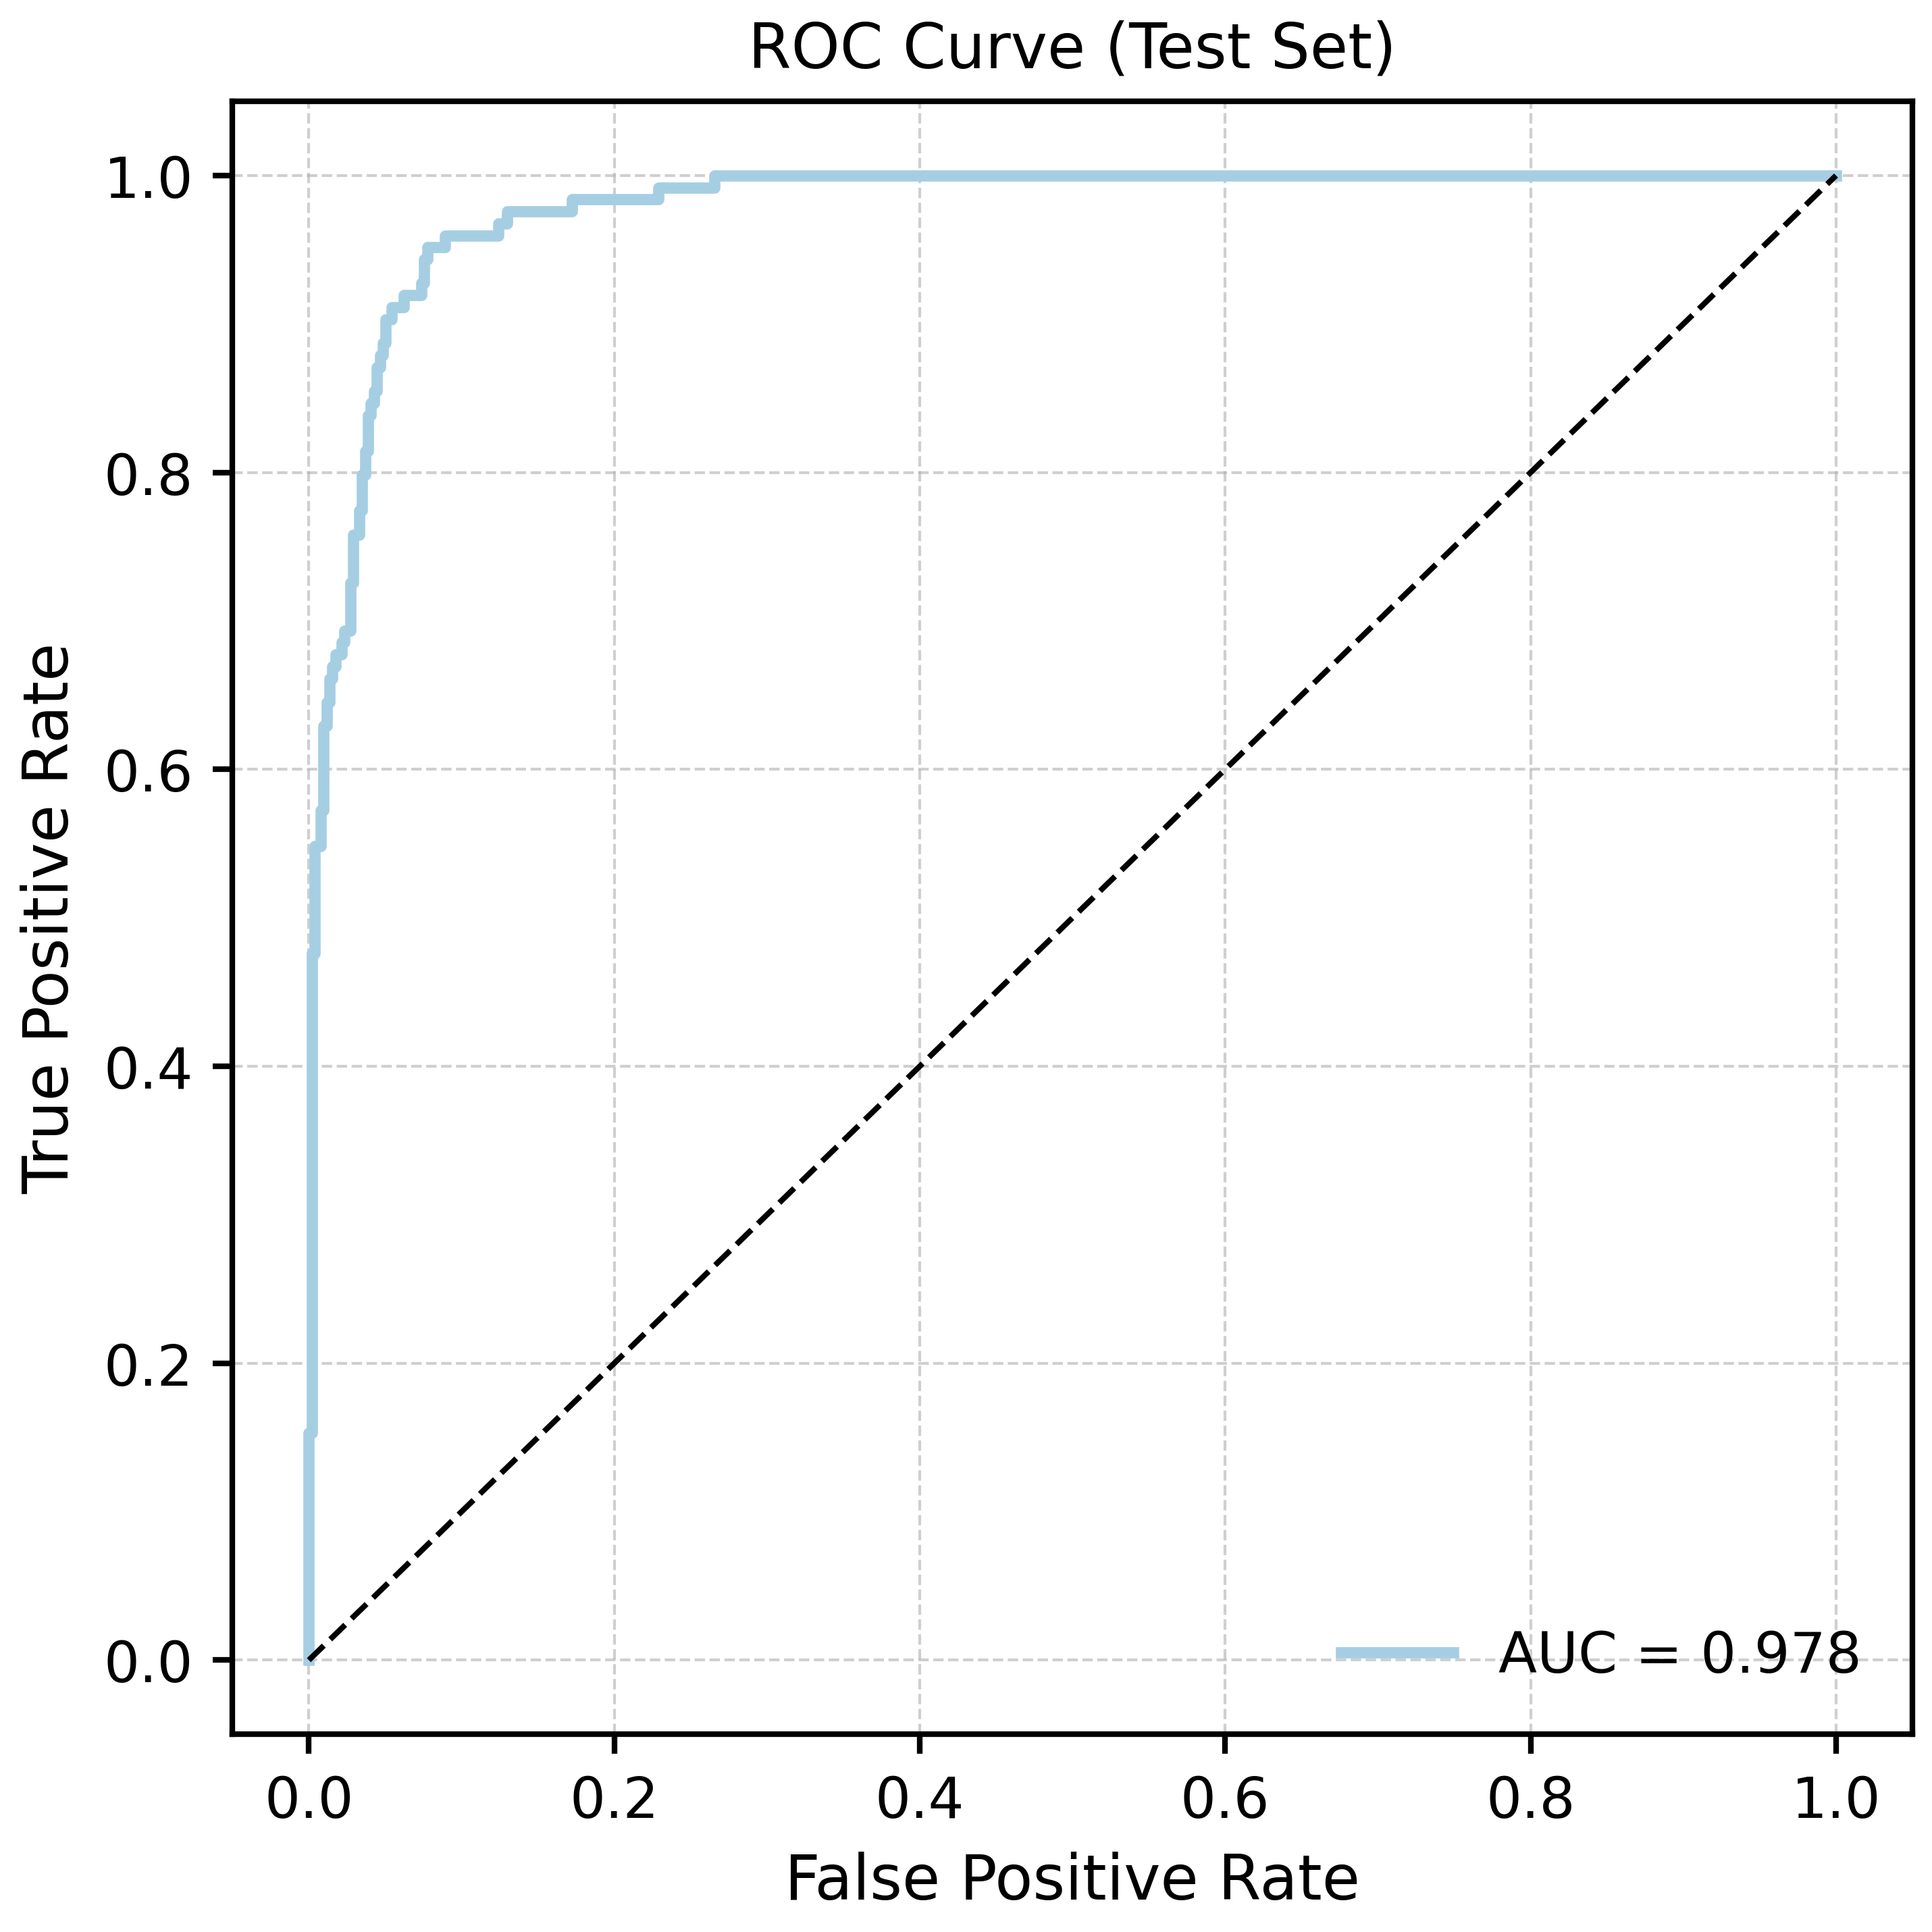

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# (권장) 안전하게 shape/dtype 통일
all_labels = np.asarray(all_labels).astype(int).ravel()
all_probs  = np.asarray(all_probs).astype(float).ravel()

print("labels unique:", np.unique(all_labels))
print("probs range:", float(all_probs.min()), "~", float(all_probs.max()))

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print("ROC AUC:", roc_auc)

ROC_COLOR = "#A6CEE3"
BASELINE_COLOR = "black"

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color=ROC_COLOR, linewidth=2.0, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color=BASELINE_COLOR, linewidth=1.0)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend(frameon=False)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()

os.makedirs(SAVE_DIR, exist_ok=True)
plt.savefig(os.path.join(SAVE_DIR, "roc_curve(2-1).png"), dpi=200, bbox_inches="tight")
plt.show()


#PR_curve

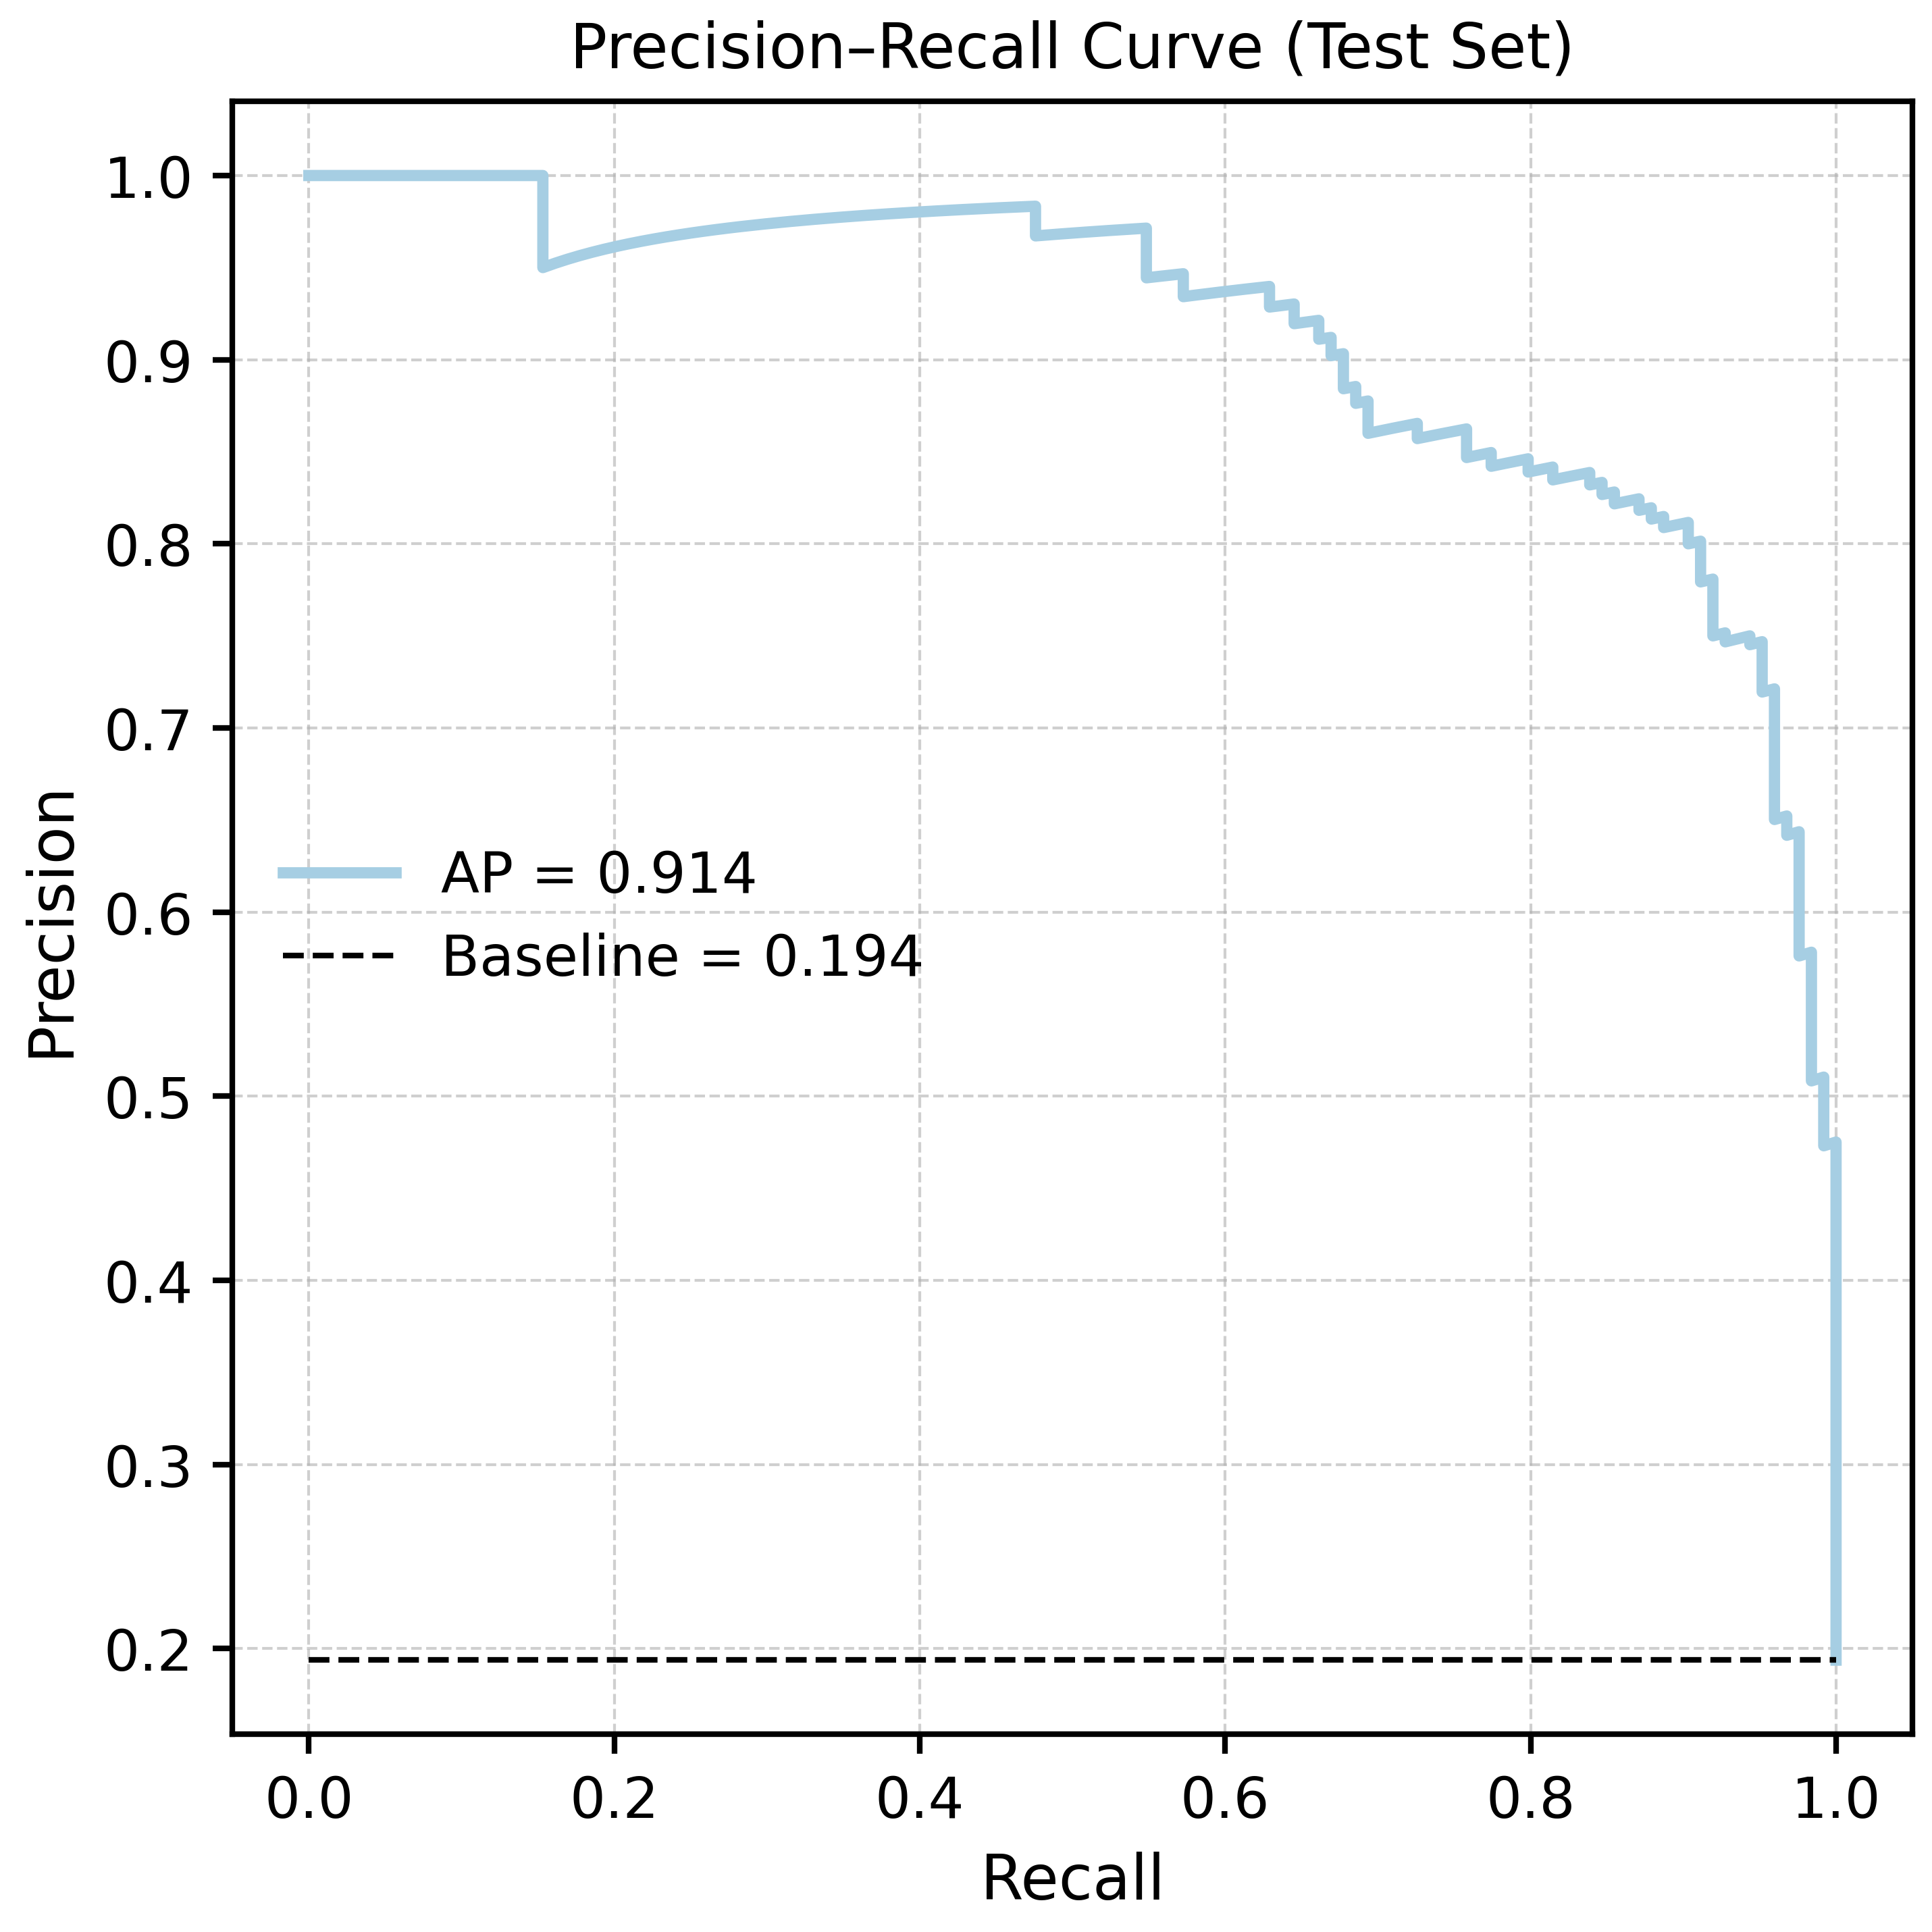

Average Precision (AP): 0.9142839172745207


In [ ]:
#===============================================================================
# PR
#===============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# (권장) 안전하게 shape/dtype 통일
all_labels = np.asarray(all_labels).astype(int).ravel()
all_probs  = np.asarray(all_probs).astype(float).ravel()

# ---- color palette ----
PR_COLOR = "#A6CEE3"
BASELINE_COLOR = "black"

# ---- compute PR ----
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)
pos_rate = all_labels.mean()  # PR baseline

# ---- plot ----
plt.figure(figsize=(5, 5))

plt.plot(
    recall, precision,
    color=PR_COLOR,
    linewidth=2.0,
    label=f"AP = {ap:.3f}"
)

# baseline
plt.plot(
    [0, 1], [pos_rate, pos_rate],
    linestyle="--",
    color=BASELINE_COLOR,
    linewidth=1.0,
    label=f"Baseline = {pos_rate:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")

plt.legend(frameon=False)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "pr_curve(2-1).png"), dpi=600, bbox_inches="tight")
plt.show()

print("Average Precision (AP):", ap)


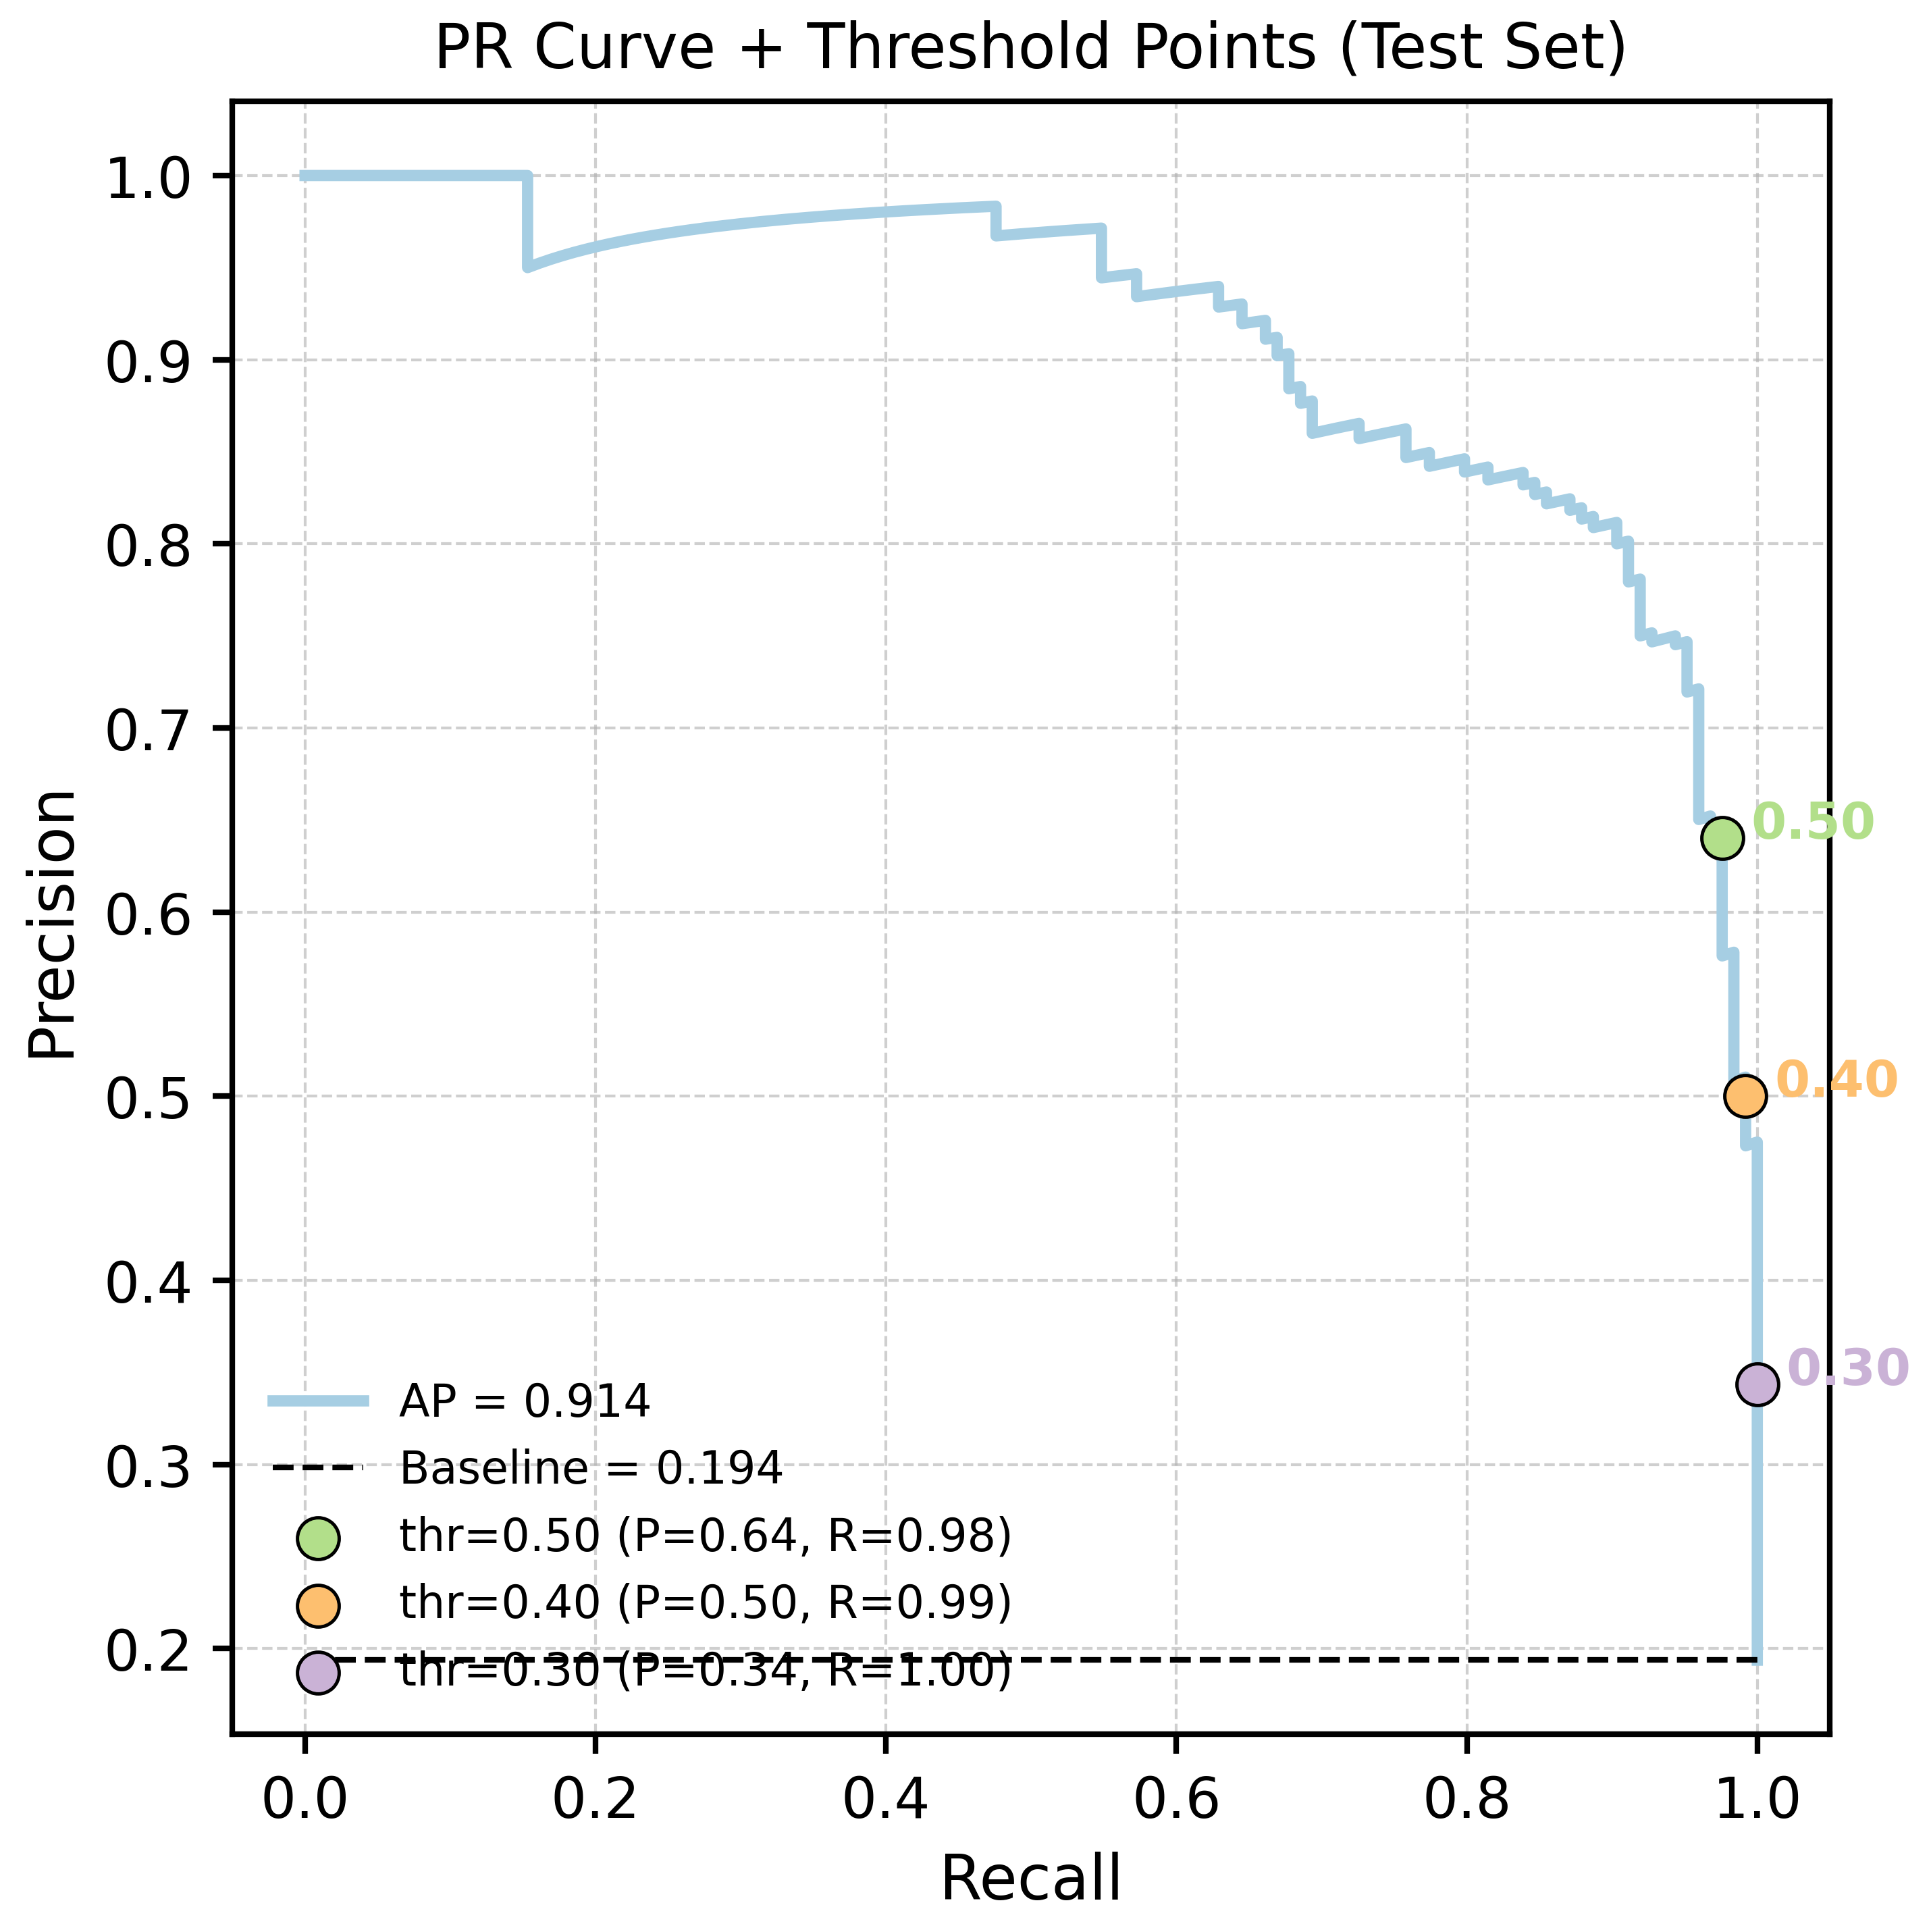

In [ ]:
#===============================================================================
# PR Curve + threshold points (colored: 0.5/0.4/0.3)
#===============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score
)

# (권장) 안전하게 shape/dtype 통일
all_labels = np.asarray(all_labels).astype(int).ravel()
all_probs  = np.asarray(all_probs).astype(float).ravel()

os.makedirs(SAVE_DIR, exist_ok=True)

# ---- color palette (ROC/PR 톤 유지) ----
PR_COLOR = "#A6CEE3"
BASELINE_COLOR = "black"

# threshold 점 색상(서로 확실히 구분되는 색)
THR_COLORS = {
    0.50: "#B2DF8A",  # 그린
    0.40: "#FDBF6F",  # 오렌지
    0.30: "#CAB2D6",  # 퍼플
}

# ---- compute PR ----
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)
pos_rate = all_labels.mean()  # PR baseline

thresholds_to_mark = [0.5, 0.4, 0.3]

# ---- plot ----
plt.figure(figsize=(5, 5))

# PR curve
plt.plot(
    recall, precision,
    color=PR_COLOR,
    linewidth=2.0,
    label=f"AP = {ap:.3f}"
)

# baseline
plt.plot(
    [0, 1], [pos_rate, pos_rate],
    linestyle="--",
    color=BASELINE_COLOR,
    linewidth=1.0,
    label=f"Baseline = {pos_rate:.3f}"
)

# threshold points
for thr in thresholds_to_mark:
    y_pred = (all_probs >= thr).astype(int)
    p = precision_score(all_labels, y_pred, zero_division=0)
    r = recall_score(all_labels, y_pred, zero_division=0)

    c = THR_COLORS.get(float(thr), "black")

    # point
    plt.scatter(
        r, p,
        color=c,
        s=55,
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
        label=f"thr={thr:.2f} (P={p:.2f}, R={r:.2f})"
    )

    # text label (색상 동일)
    plt.text(
        r + 0.02, p,
        f"{thr:.2f}",
        fontsize=9,
        color=c,
        weight="bold"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve + Threshold Points (Test Set)")

# legend가 길어질 수 있으니 위치 조정
plt.legend(frameon=False, fontsize=8, loc="lower left")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "pr_curve_threshold_colored(2-1).png"), dpi=200, bbox_inches="tight")
plt.show()


# confusion_matrix

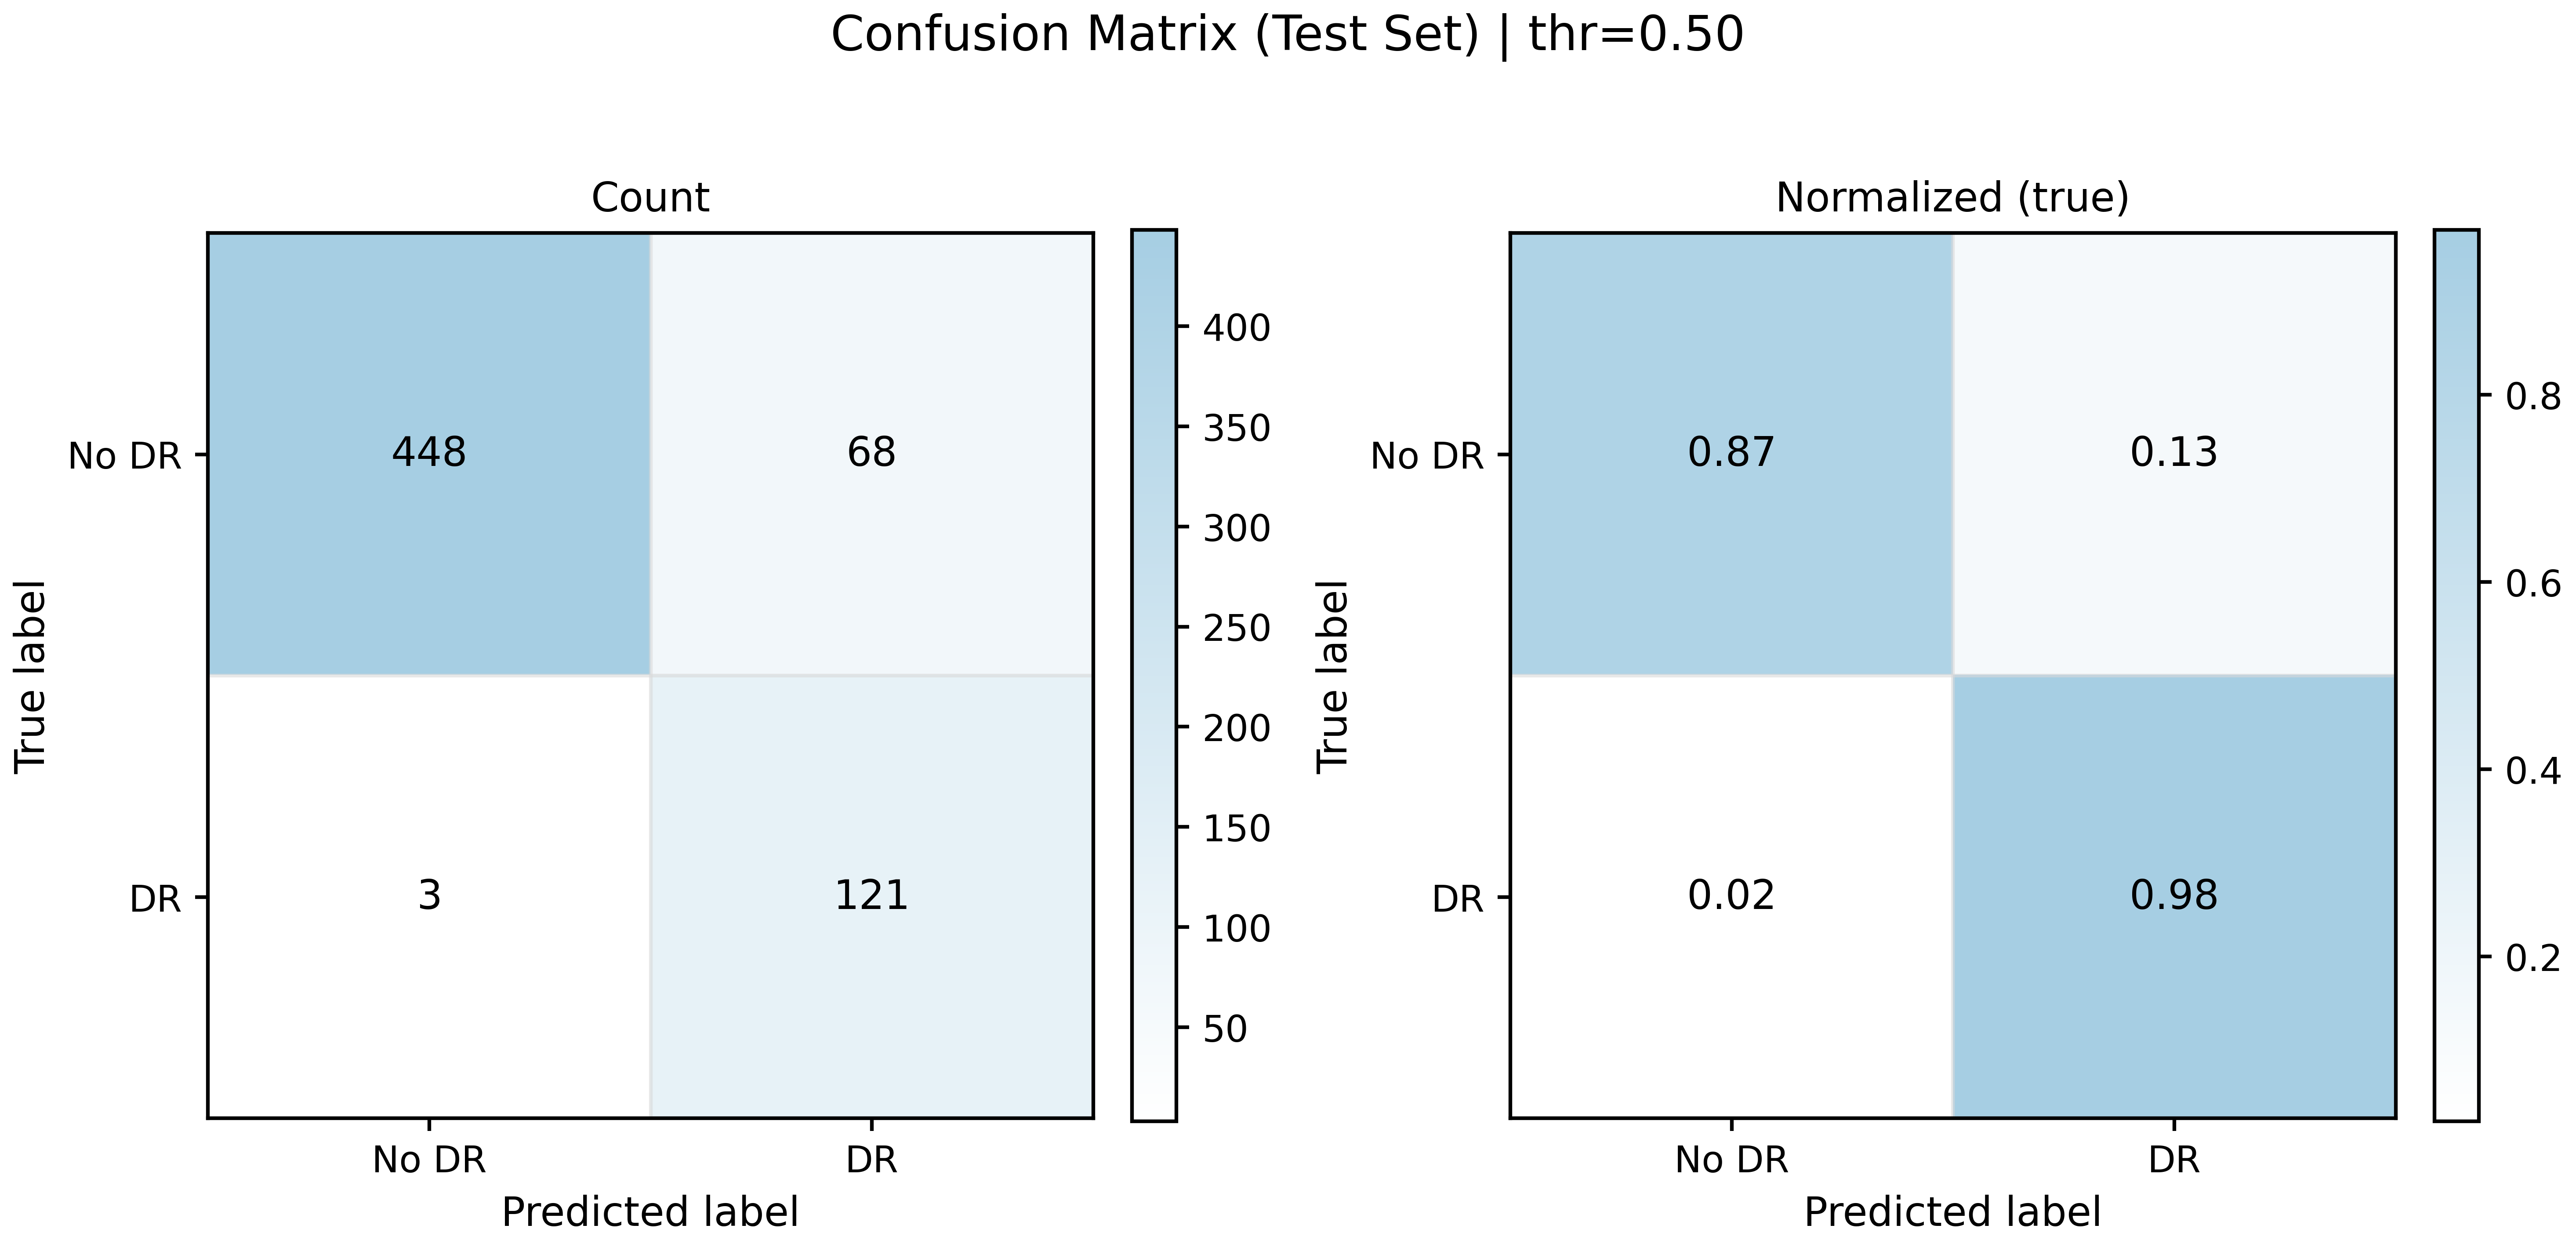

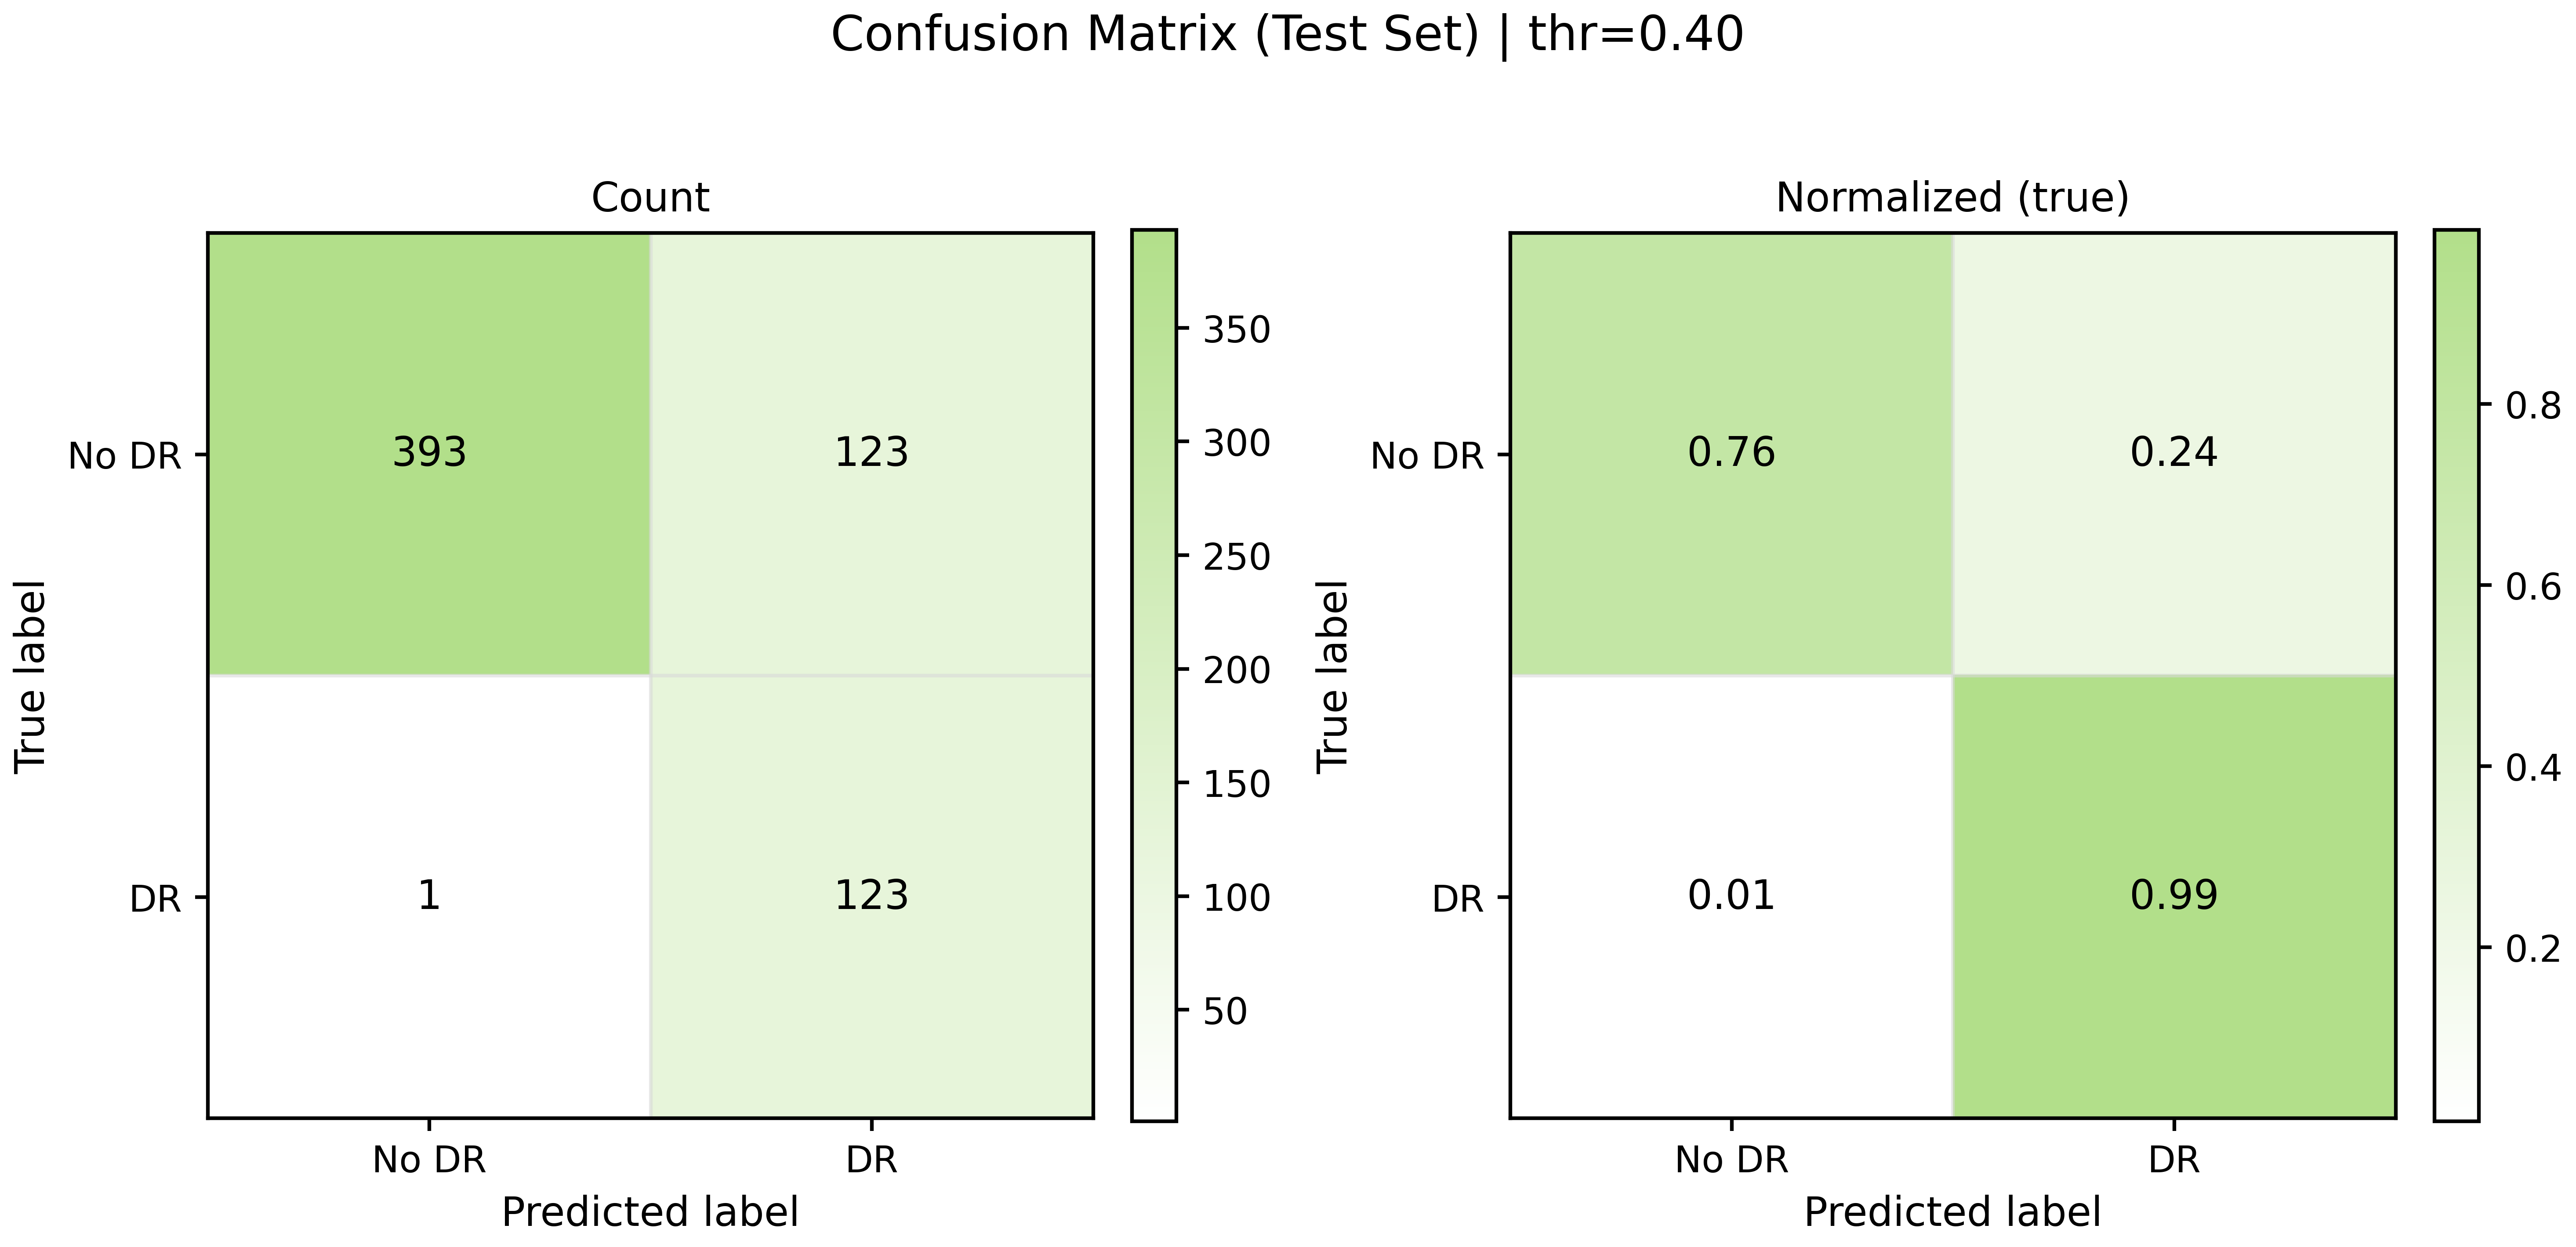

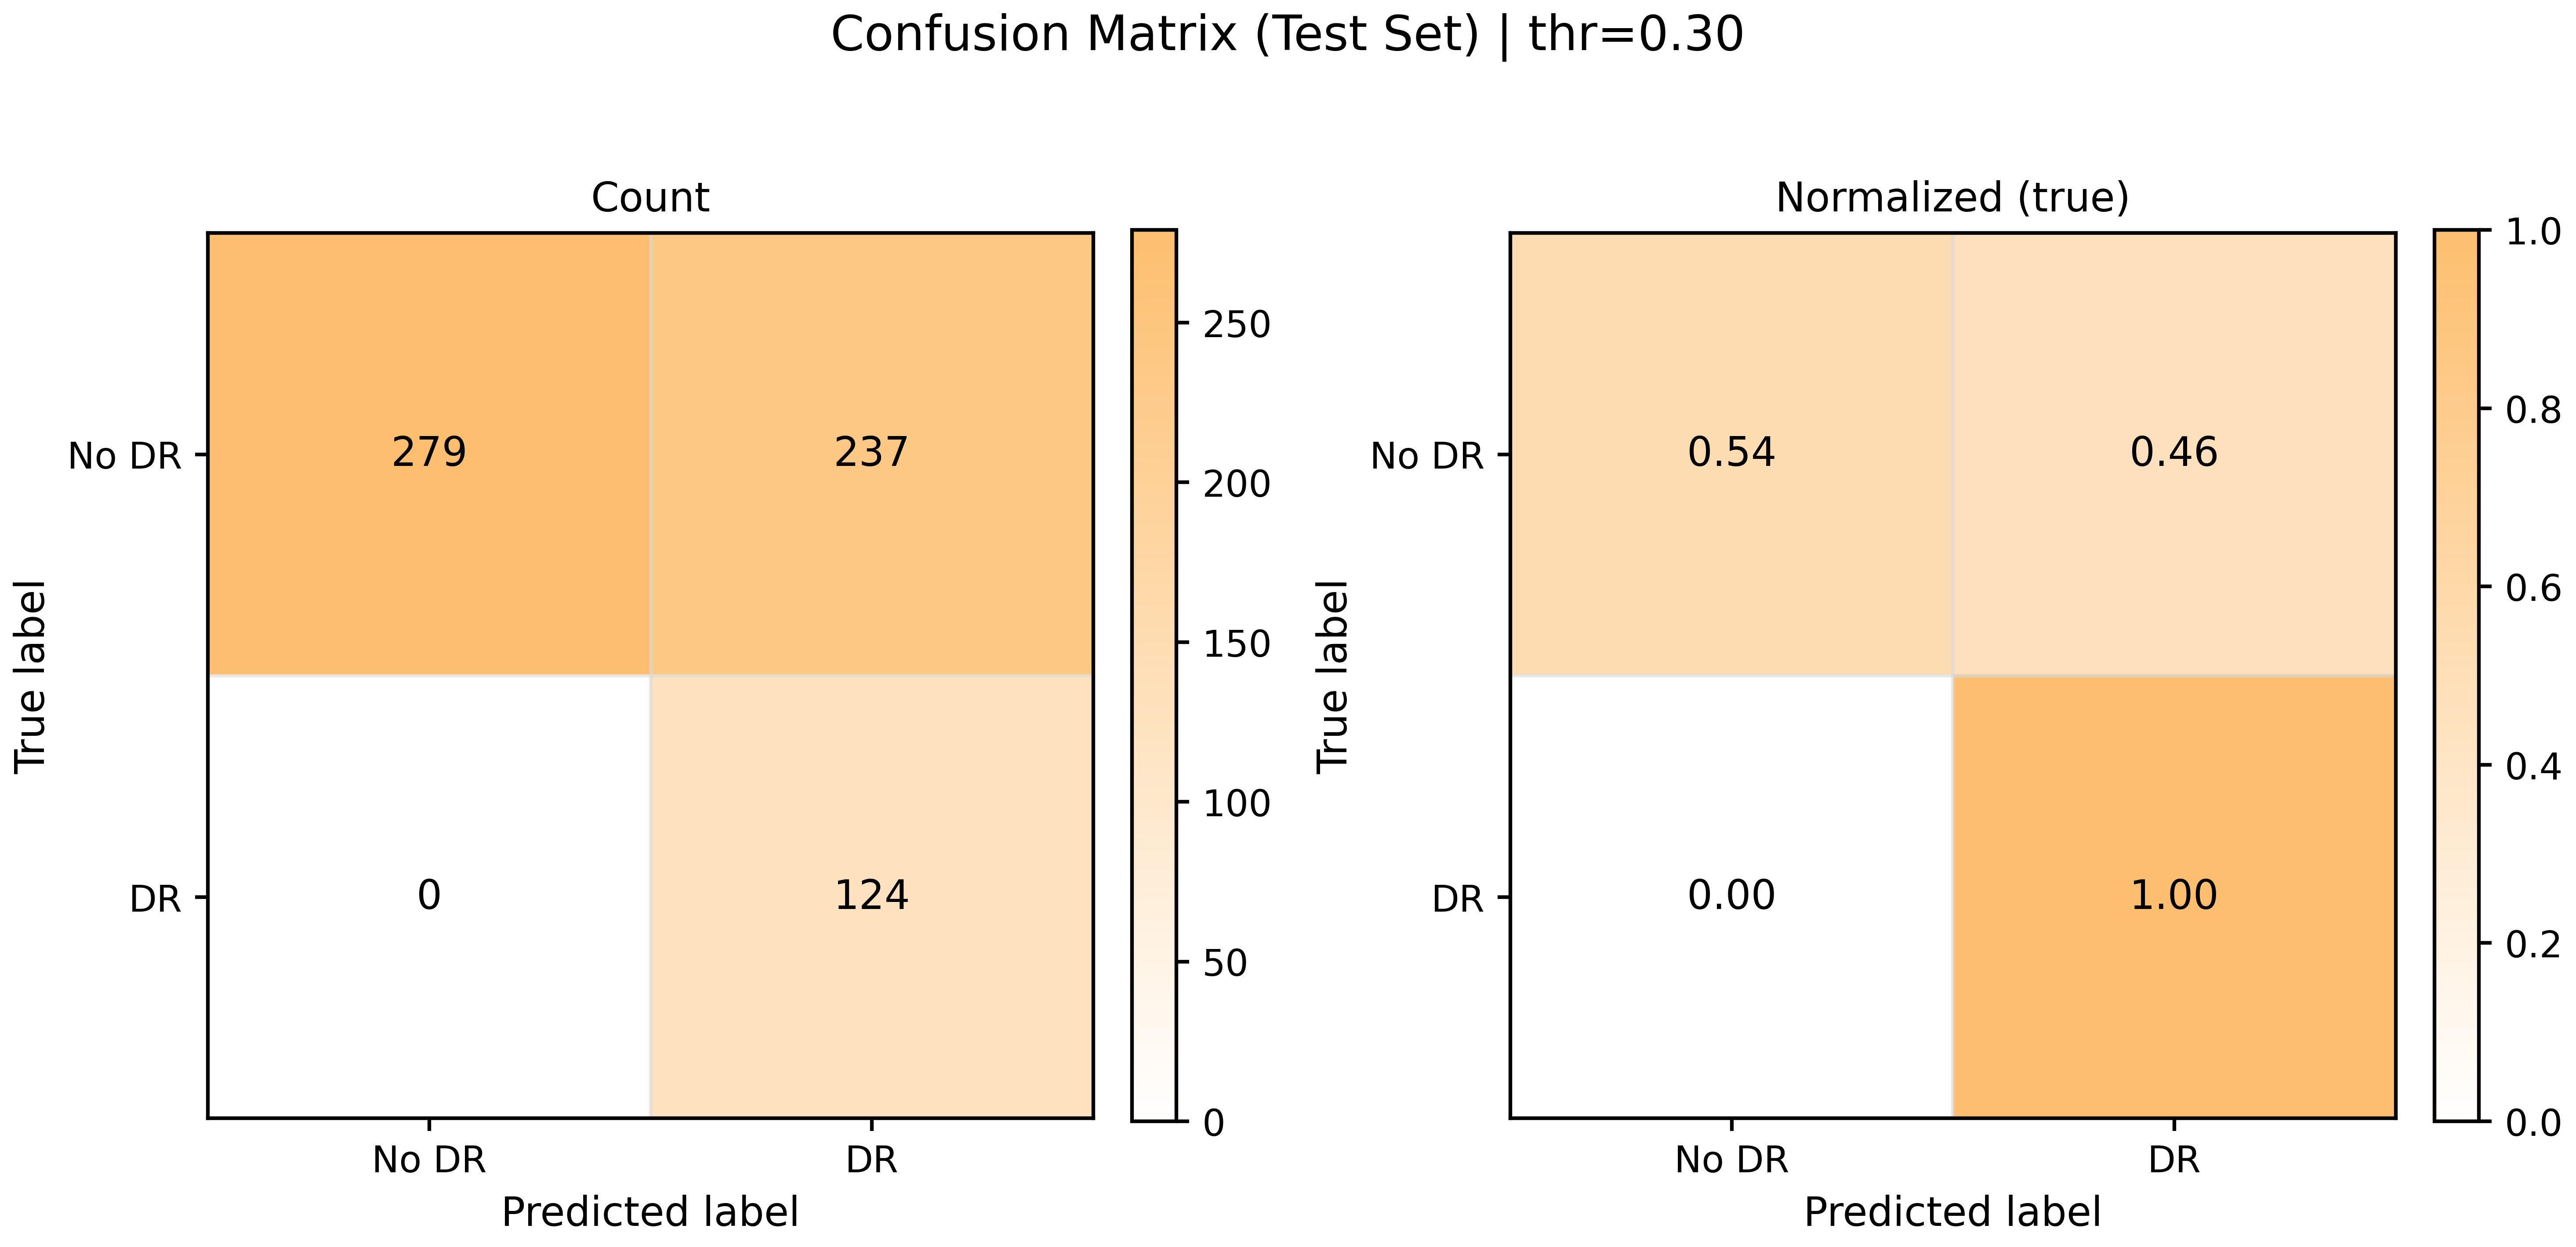

In [ ]:
#===============================================================================
# Confusion Matrix 2-in-1: (Left) Count, (Right) normalize="true"
#  - ROC/PR 스타일(깔끔, grid, 저장 규칙) + threshold별 색상 팔레트 적용 가능
#===============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

# (권장) shape/dtype 통일
all_labels = np.asarray(all_labels).astype(int).ravel()
all_probs  = np.asarray(all_probs).astype(float).ravel()

os.makedirs(SAVE_DIR, exist_ok=True)

# ---- 너 팔레트(원하면 threshold마다 바꿔서 사용) ----
PALETTE = [
    "#A6CEE3",
    "#B2DF8A",
    "#FDBF6F",
    "#CAB2D6",
    "#FB9A99",
]

def make_cmap_from_hex(hex_color, name="custom"):
    return LinearSegmentedColormap.from_list(name, ["#FFFFFF", hex_color])

def plot_cm_2in1(
    y_true, y_prob, thr=0.5,
    hex_color="#A6CEE3",
    labels=("No DR", "DR"),
    save_name=None,
    title=None
):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob).astype(float).ravel()
    y_pred = (y_prob >= thr).astype(int)

    cm_cnt  = confusion_matrix(y_true, y_pred, normalize=None)
    cm_true = confusion_matrix(y_true, y_pred, normalize="true")

    cmap = make_cmap_from_hex(hex_color, name=f"cm_thr_{thr}")
    GRID_COLOR = "#D9D9D9"

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 5x5 두 장 느낌

    if title is None:
        title = f"Confusion Matrix (thr={thr:.2f})"
    fig.suptitle(title)

    def draw(ax, cm, subtitle, fmt, show_cbar=True):
        im = ax.imshow(cm, cmap=cmap)
        ax.set_title(subtitle)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(labels); ax.set_yticklabels(labels)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")

        # cell 값 표시
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i, j]:{fmt}}", ha="center", va="center")

        # 은은한 grid(ROC/PR 톤)
        ax.grid(False)
        ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
        ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
        ax.grid(which="minor", color=GRID_COLOR, linestyle="-", linewidth=1)
        ax.tick_params(which="minor", bottom=False, left=False)

        if show_cbar:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    draw(axes[0], cm_cnt,  "Count",            "d",   show_cbar=True)
    draw(axes[1], cm_true, "Normalized (true)","0.2f",show_cbar=True)

    plt.tight_layout()

    if save_name is None:
        save_name = f"confusion_matrix_2in1(2-8)_thr_{thr:.2f}.png"

    plt.savefig(os.path.join(SAVE_DIR, save_name), dpi=200, bbox_inches="tight")
    plt.show()

    return cm_cnt, cm_true


# =========================
# 사용 예시 2) threshold 여러 개를 팔레트로 색 다르게 저장
# =========================
threshold_list = [0.50, 0.40, 0.30]
for i, thr in enumerate(threshold_list):
    plot_cm_2in1(
        all_labels, all_probs,
        thr=thr,
        hex_color=PALETTE[i % len(PALETTE)],
        save_name=f"confusion_matrix_2in1(2-8)_thr_{thr:.2f}.png",
        title=f"Confusion Matrix (Test Set) | thr={thr:.2f}"
    )


# Calibration curve

Brier score: 0.11745566899993584


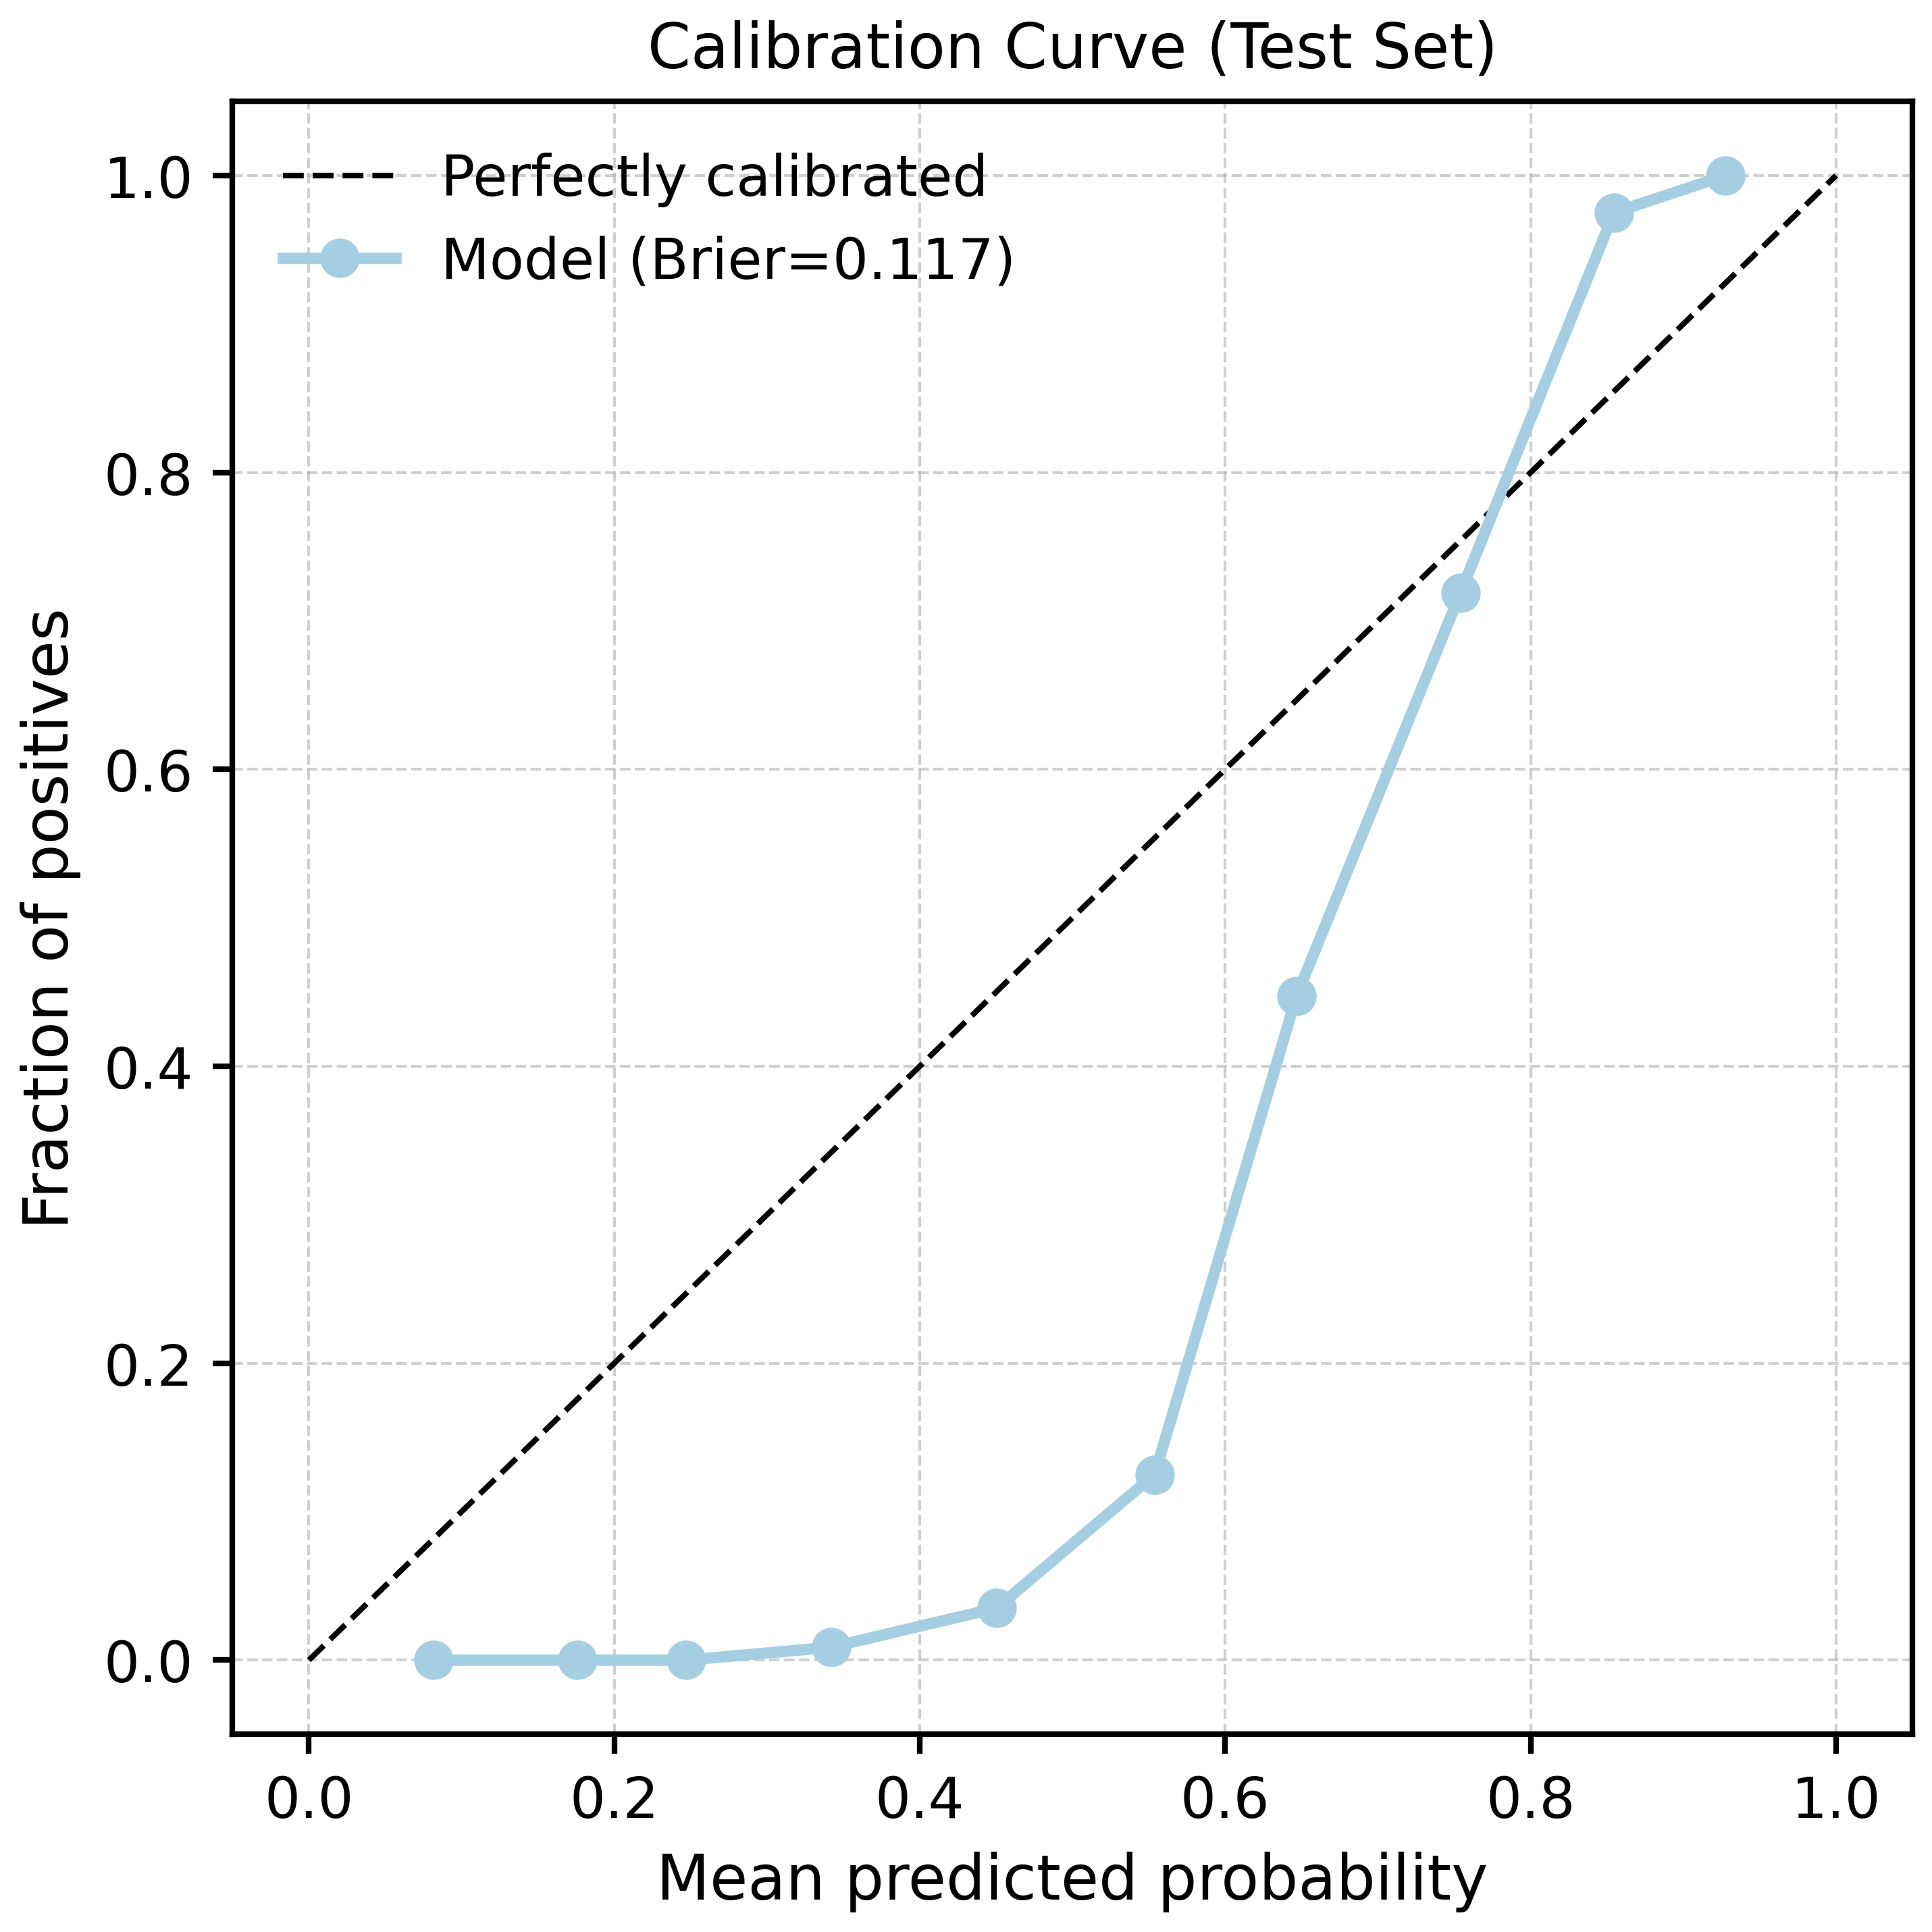

In [ ]:
#===============================================================================
# Calibration Curve (publication-ready)
#===============================================================================
#===============================================================================
# Calibration Curve (Reliability Diagram)
#===============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# (권장) 안전하게 shape/dtype 통일
all_labels = np.asarray(all_labels).astype(int).ravel()
all_probs  = np.asarray(all_probs).astype(float).ravel()

os.makedirs(SAVE_DIR, exist_ok=True)

# ---- style palette (ROC/PR 톤 유지) ----
CAL_COLOR = "#A6CEE3"
BASELINE_COLOR = "black"

# ---- compute calibration ----
# n_bins: 보통 10~20 추천 (데이터가 적으면 10)
prob_true, prob_pred = calibration_curve(
    all_labels,
    all_probs,
    n_bins=10,
    strategy="uniform"   # "uniform" or "quantile"
)

brier = brier_score_loss(all_labels, all_probs)
print("Brier score:", brier)

# ---- plot ----
plt.figure(figsize=(5, 5))

# perfect calibration line
plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color=BASELINE_COLOR,
    linewidth=1.0,
    label="Perfectly calibrated"
)

# model calibration
plt.plot(
    prob_pred, prob_true,
    marker="o",
    linewidth=2.0,
    color=CAL_COLOR,
    label=f"Model (Brier={brier:.3f})"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve (Test Set)")

plt.legend(frameon=False)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "calibration_curve(2-1).png"), dpi=600, bbox_inches="tight")
plt.show()


# Loss curve(근사)

In [ ]:
# epoch별 근사치 (training_history.png 기반 추정)
epochs = list(range(0, 24))

train_loss = [
    0.02503, 0.02503, 0.02343, 0.02028, 0.02222, 0.02018,
    0.01964, 0.01944, 0.01955, 0.01714, 0.01700, 0.01832,
    0.01612, 0.01436, 0.01456, 0.01334, 0.01434, 0.01340,
    0.01172, 0.01193, 0.01211, 0.01247, 0.01108, 0.01065
]

val_loss = [
    0.01721, 0.01994, 0.01469, 0.01314, 0.01380, 0.02621,
    0.01490, 0.02210, 0.01502, 0.01352, 0.01299, 0.01273,
    0.01380, 0.01334, 0.01444, 0.01500, 0.01438, 0.01273,
    0.01354, 0.01561, 0.01403, 0.01390, 0.01320, 0.01425
]

train_auc = [
    0.78437, 0.83460, 0.86850, 0.88041, 0.83833, 0.86146,
    0.85153, 0.86410, 0.84662, 0.85527, 0.87672, 0.85228,
    0.85775, 0.85783, 0.91473, 0.89421, 0.85848, 0.87029,
    0.90637, 0.91915, 0.87667, 0.88361, 0.91067, 0.89548
]

val_auc = [
    0.95292, 0.95009, 0.96045, 0.95104, 0.96422, 0.95763,
    0.96611, 0.96307, 0.96658, 0.94599, 0.96179, 0.96554,
    0.96176, 0.96220, 0.95763, 0.96435, 0.96343, 0.96118,
    0.96302, 0.96163, 0.96263, 0.96220, 0.96168, 0.95763
]

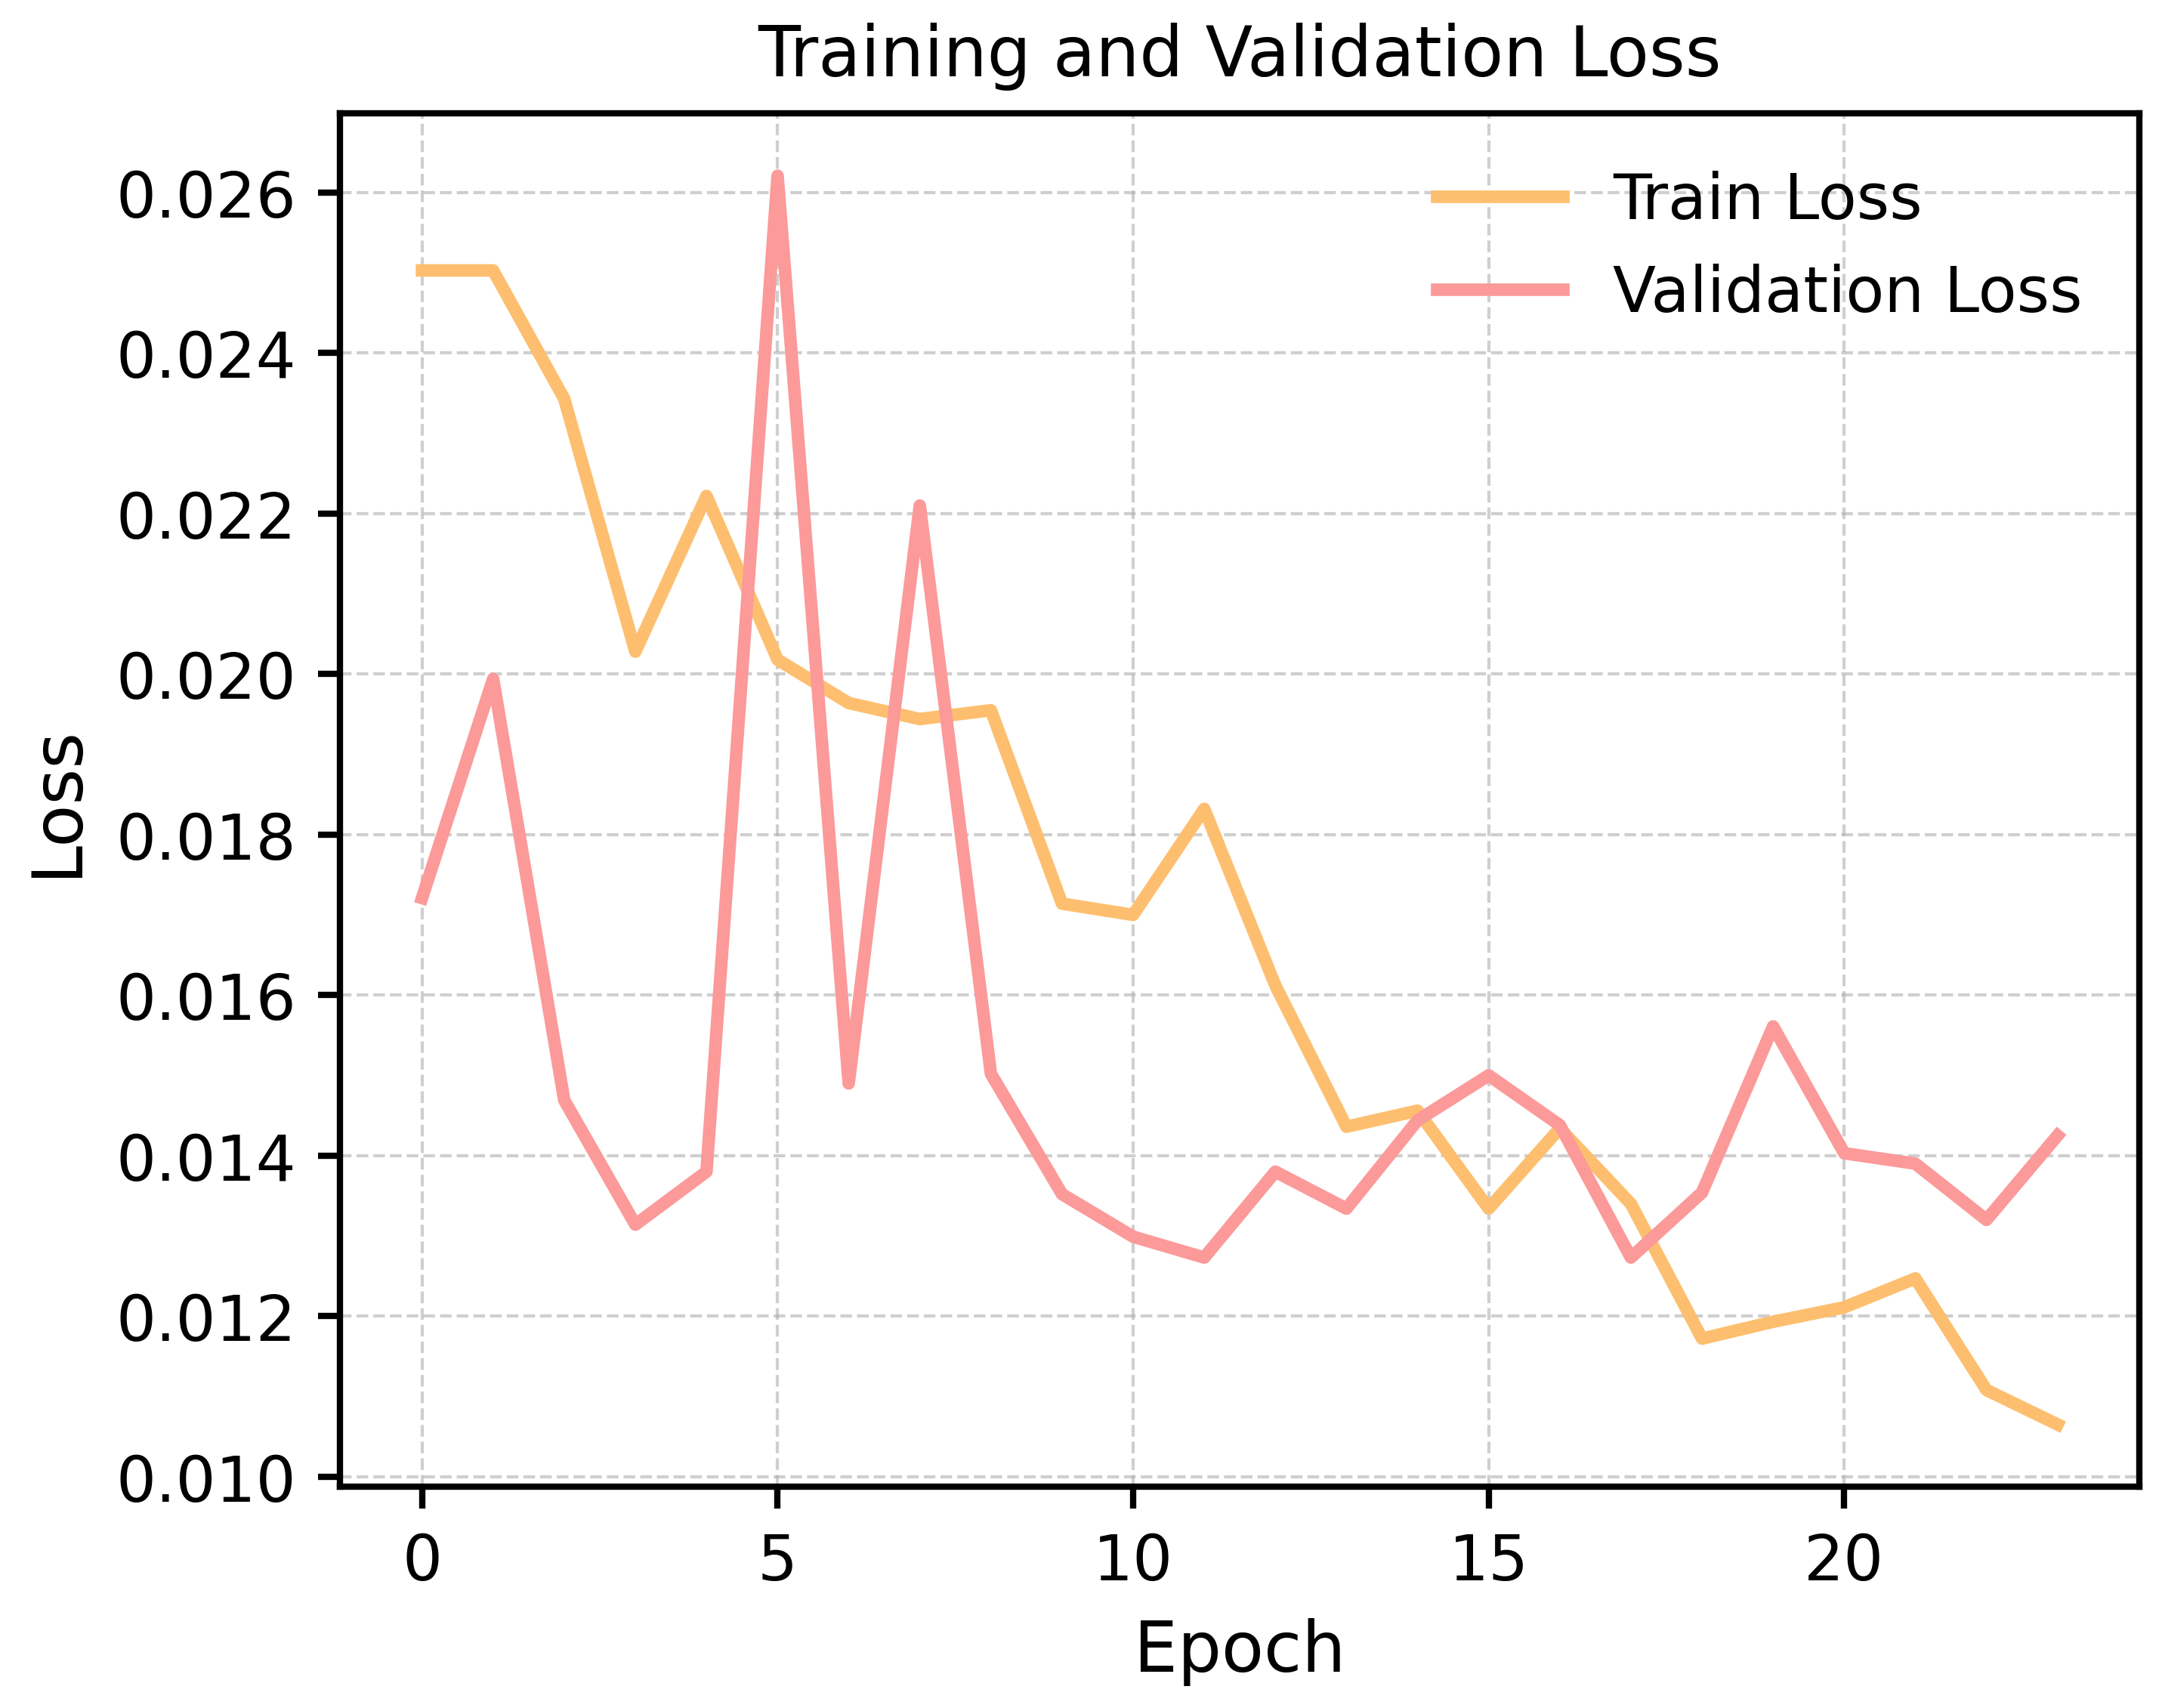

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# ===== 스타일 =====
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "savefig.bbox": "tight"
})

PALETTE = {
    "train": "#FDBF6F",  # orange
    "val":   "#FB9A99",  # red
    "auc":   "#A6CEE3"   # blue
}

SAVE_DIR = "/content/drive/MyDrive/ColabNotebooks/RFMiD_A/visualization"
os.makedirs(SAVE_DIR, exist_ok=True)

# ===== Loss curve =====
plt.figure(figsize=(5,4))
plt.plot(epochs, train_loss, color=PALETTE["train"], lw=2, label="Train Loss")
plt.plot(epochs, val_loss,   color=PALETTE["val"],   lw=2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend(frameon=False)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "loss_curve_reconstructed(2-1).png"), dpi=600)
plt.show()

# AUC curve(근사)

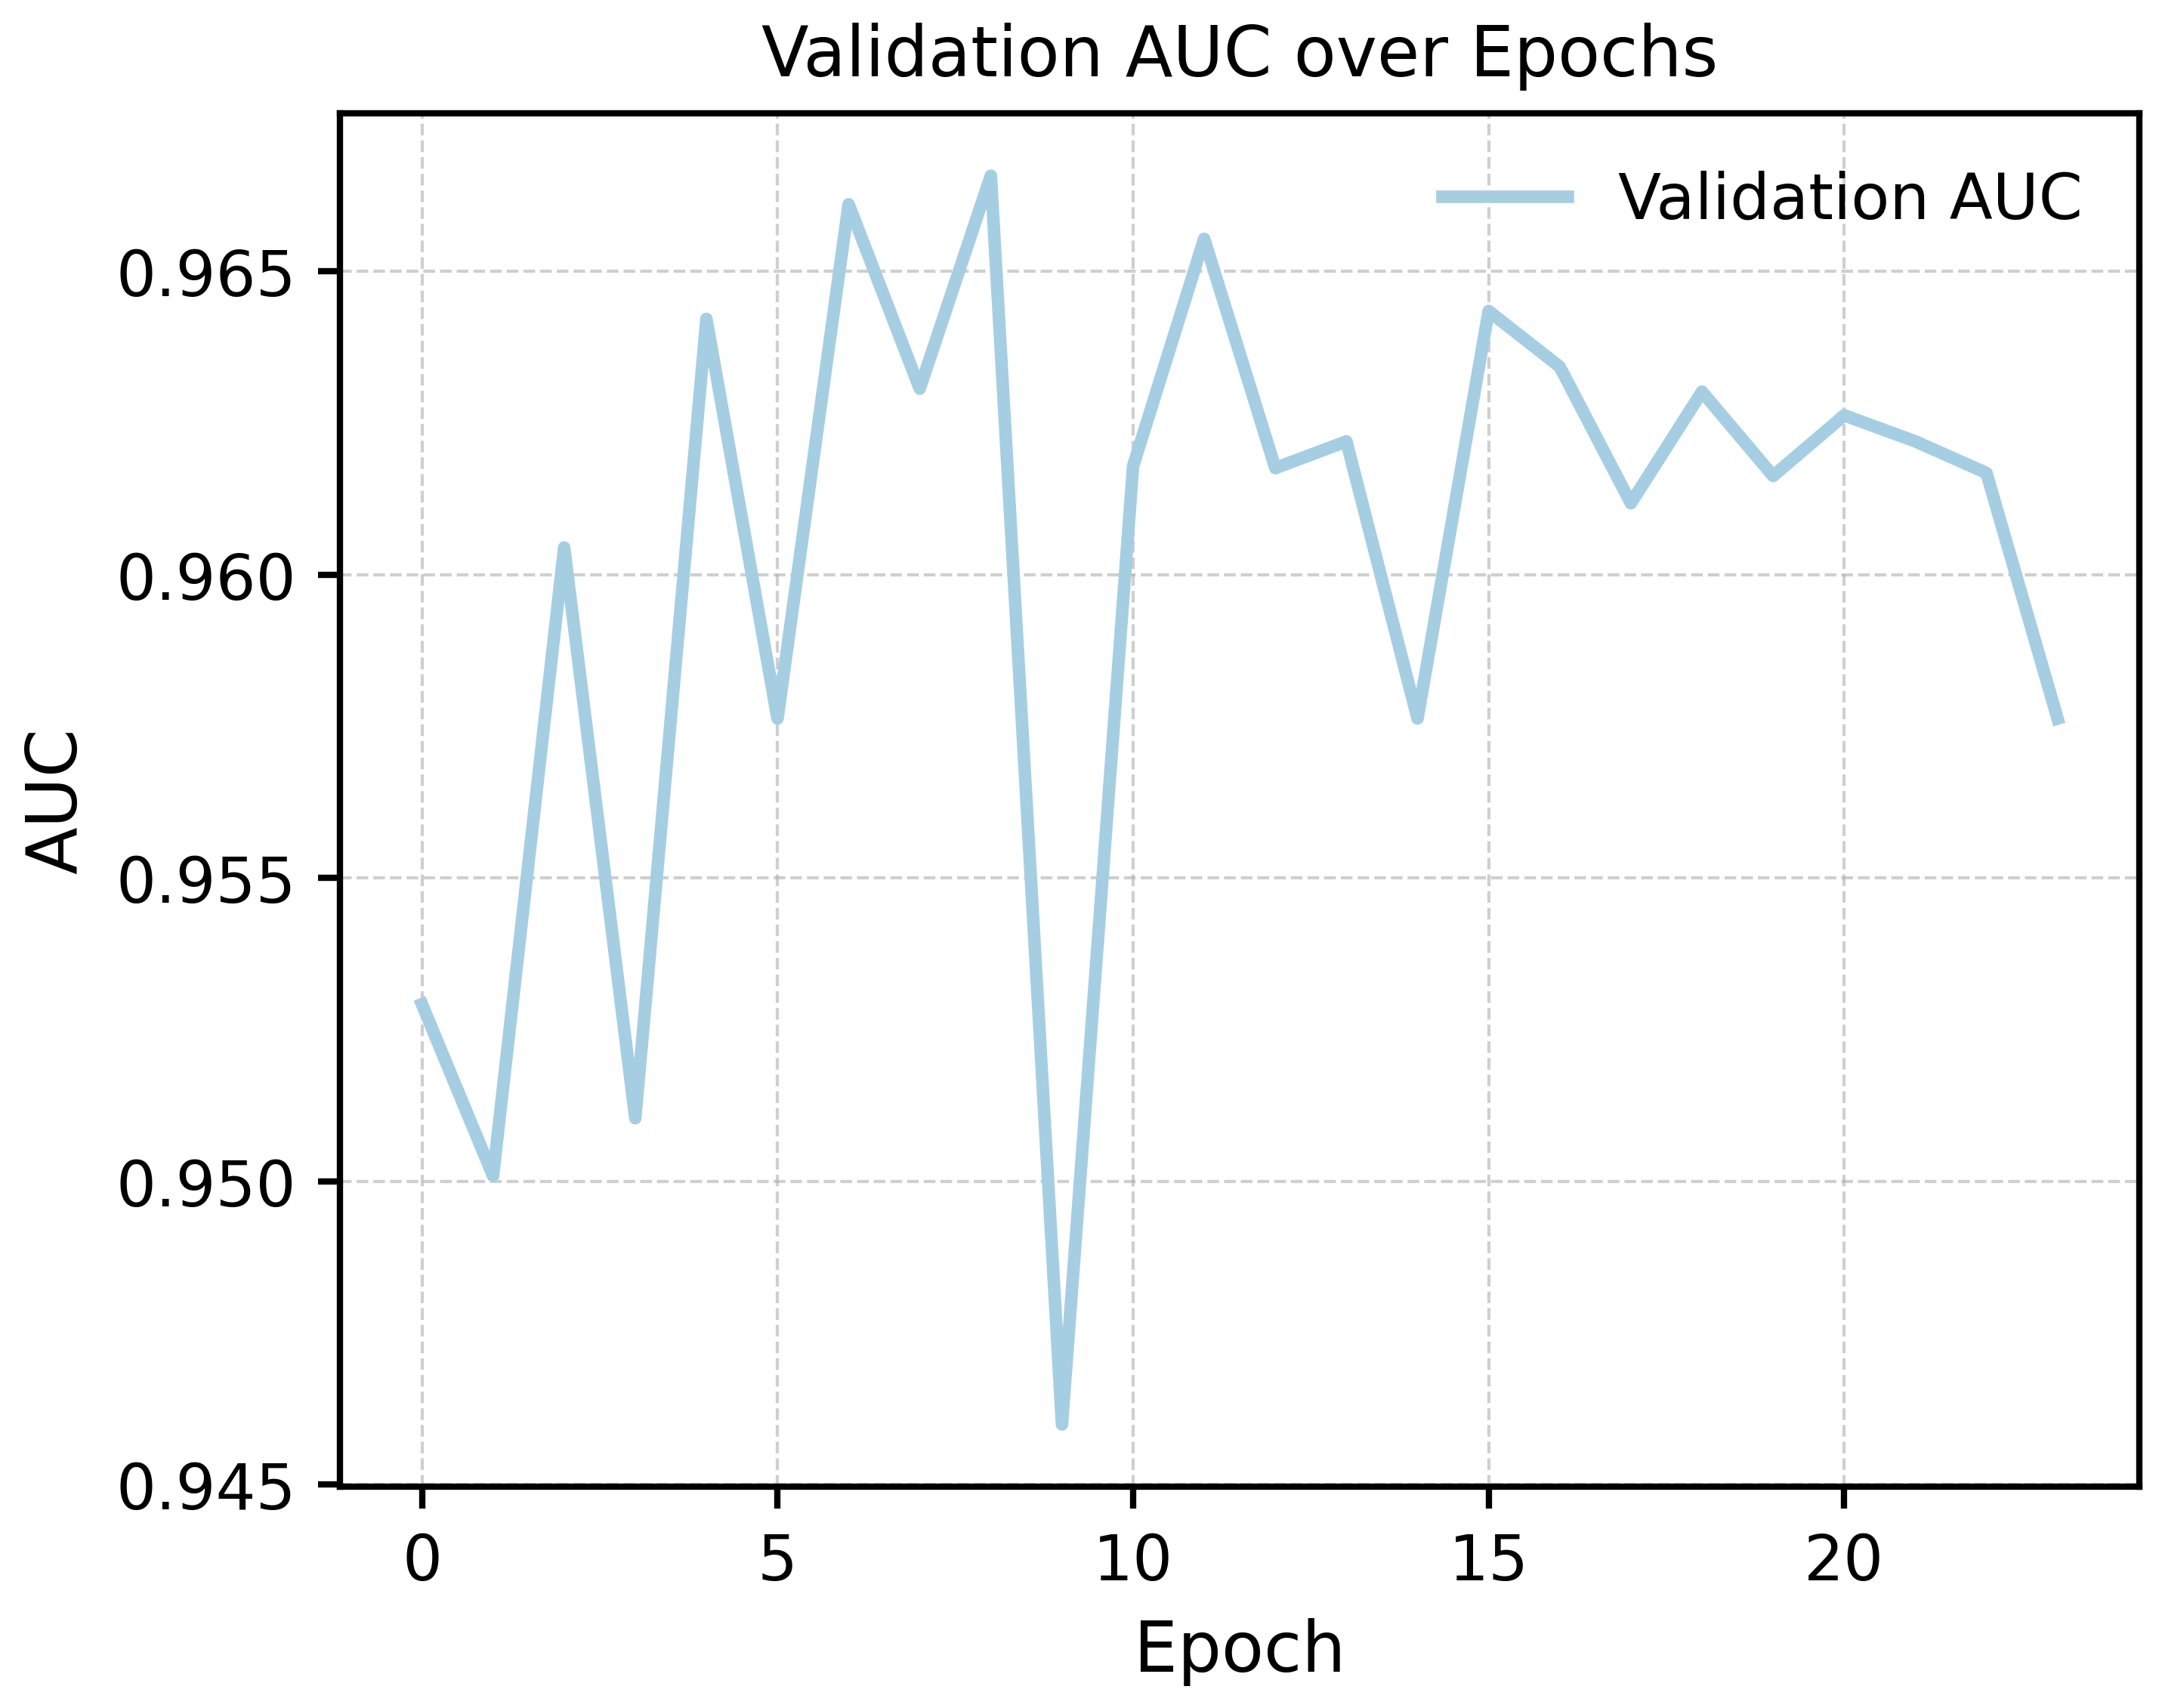

In [ ]:
# ===== AUC curve =====
plt.figure(figsize=(5,4))
plt.plot(epochs, val_auc, color=PALETTE["auc"], lw=2, label="Validation AUC")

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC over Epochs")
plt.legend(frameon=False)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "auc_curve_reconstructed(2-1).png"), dpi=200)
plt.show()
